# ⚽ TASK 1. 데이터 출처 설명 및 데이터 불러오기

---

## 1.1 데이터 선정 이유 및 도메인 개요
평소 축구 경기를 시청하며 단순히 승패를 확인하는 것을 넘어, 선수의 움직임 하나하나와 전술적 흐름에 깊은 관심을 가져왔습니다. "왜 저 선수는 저 타이밍에 저 공간으로 패스를 보냈을까?"라는 의문은 제가 축구 데이터를 분석하게 된 가장 큰 동기입니다.

현대 축구에서 승패는 개별 선수의 기량을 넘어, **보이지 않는 공간을 창출하고 유기적인 팀 패턴을 만드는 능력**에서 결정됩니다. 기존 분석은 단편적인 기록에 그쳤으나, 진정한 통찰은 복합적인 맥락 속에서 나옵니다. 저는 제가 좋아하는 축구라는 도메인을 데이터로 직접 다루며, K리그 실제 데이터를 기반으로 이어지는 패스가 도달할 최적의 위치를 예측함으로써 **데이터 기반 전술 분석의 가능성**을 직접 확인해보고자 이 데이터를 선정하게 되었습니다.

---

## 1.2 데이터 출처 및 제공처
* **데이터셋 명칭**: K리그 경기 내 최종 패스 좌표 예측 AI 모델 개발 데이터
* **주최/주관**: 서울시립대학교, 한국프로축구연맹
* **운영**: 데이콘 (DACON)

---

## 1.3 데이터 상세 명세 (Column Specifications)

제공된 데이터는 경기 기본 정보가 담긴 메타 데이터(`match_info.csv`)와 실제 경기 내 모든 행동이 기록된 이벤트 데이터(`train.csv`, `test.csv`)로 구성됩니다.

### **① match_info.csv (경기 메타 데이터)**
경기의 전반적인 배경 정보를 포함하고 있습니다.

| 컬럼명 | 설명 | 데이터 타입 | 비고 |
| :--- | :--- | :--- | :--- |
| `game_id` | 경기를 구분하는 고유 ID | object | |
| `season_id` | 시즌 고유 ID | object | e.g., 2024시즌 |
| `competition_name` | 대회 이름 (영문) | object | K리그1, FA컵 등 |
| `game_date` | 실제 경기 날짜 | datetime64 | |
| `home_team_name_ko` | 홈 팀 이름 (한글) | object | |
| `away_team_name_ko` | 어웨이 팀 이름 (한글) | object | |
| `home_score / away_score` | 홈/어웨이 팀 최종 득점 | int64 | |

### **② train.csv / test.csv (이벤트 로그 데이터)**
선수들의 모든 액션이 좌표 및 시간 단위로 기록된 시계열 데이터입니다.

| 컬럼명 | 설명 | 데이터 타입 | 상세 내용 |
| :--- | :--- | :--- | :--- |
| `game_episode` | `{game_id}_{episode_id}` | object | 공이 라인 밖을 나가기 전까지의 플레이 단위 |
| `time_seconds` | Period 시작 후 경과 시간 | float64 | 에피소드 내 시간적 일관성 유지 |
| `type_name` | 이벤트의 종류 | object | Pass, Shot, Cross, Tackle 등 |
| `result_name` | 이벤트의 성공 여부 | object | Successful, Unsuccessful 등 |
| `start_x, start_y` | 이벤트 시작 좌표 | float64 | 105 x 68 규격 상대 좌표 |
| `end_x, end_y` | 이벤트 종료 좌표 | float64 | **본 분석의 예측 목표(Target)** |

---

## 1.4 데이터의 기술적 특징 (Coordinate System)



### **1) 피파(FIFA) 표준 규격 매핑**
모든 경기장 크기 차이를 보정하고 일관된 분석을 제공하기 위해, 모든 좌표는 피파 공식 권장 경기장 규격인 **105 x 68** 크기의 그리드에 상대 좌표로 매핑되어 있습니다.
* **X축**: 0 (아군 골라인) ~ 105 (상대 골라인)
* **Y축**: 0 (왼쪽 터치라인) ~ 68 (오른쪽 터치라인)

### **2) 공격 방향의 통일 (L→R 공격)**
실제 경기에서 전/후반 팀의 공격 방향이 바뀌더라도, 모든 이벤트 데이터는 좌우/상하 반전 처리를 통해 **항상 왼쪽(x=0)에서 오른쪽(x=105)으로 공격하는 것을 기준**으로 기록되었습니다.


In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 데이터 파일 경로 설정
data_path = '/content/drive/MyDrive/epoch'

# 3. 데이터 로드
# match_info: 경기 메타 정보
match_info = pd.read_csv(os.path.join(data_path, 'match_info.csv'))

# train: 이벤트 로그 데이터
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 4. 로드 결과 확인
print(f"Match Info 데이터 크기: {match_info.shape}")
print(f"Train 이벤트 데이터(샘플) 크기: {train_df.shape}")


Match Info 데이터 크기: (228, 17)
Train 이벤트 데이터(샘플) 크기: (356721, 15)


In [ ]:
# 데이터 상위 행 출력
train_df.head()

,game_id,period_id,episode_id,time_seconds,team_id,player_id,action_id,type_name,result_name,start_x,start_y,end_x,end_y,is_home,game_episode
0,126283,1,1,0.667,2354,344559,0,Pass,Successful,52.418205,33.485444,31.322445,38.274752,True,126283_1
1,126283,1,1,3.667,2354,250036,2,Pass,Successful,32.013240,38.100808,37.371285,30.632980,True,126283_1
2,126283,1,1,4.968,2354,500145,4,Carry,NaN,37.371285,30.632980,38.391570,24.613144,True,126283_1
3,126283,1,1,8.200,2354,500145,5,Pass,Successful,38.391570,24.613144,34.573350,5.545468,True,126283_1
4,126283,1,1,11.633,2354,142106,7,Pass,Successful,34.578705,6.058256,21.274470,18.437112,True,126283_1


In [ ]:
match_info.head()

,game_id,season_id,competition_id,game_day,game_date,home_team_id,away_team_id,home_score,away_score,venue,competition_name,country_name,season_name,home_team_name,home_team_name_ko,away_team_name,away_team_name_ko
0,126283,3669,587,1,2024-03-01 05:00:00,2354,4639,1,0,문수월드컵경기장,K League 1,KR,2024,Ulsan HD FC,울산 HD FC,Pohang Steelers,포항 스틸러스
1,126284,3669,587,1,2024-03-01 07:30:00,4640,4657,1,1,전주월드컵경기장,K League 1,KR,2024,Jeonbuk Hyundai Motors,전북 현대 모터스,Daejeon Hana Citizen,대전 하나 시티즌
2,126285,3669,587,1,2024-03-02 05:00:00,4648,316,2,0,광주전용구장,K League 1,KR,2024,Gwangju FC,광주FC,FC Seoul,FC서울
3,126286,3669,587,1,2024-03-02 07:30:00,4646,4220,0,1,인천축구전용경기장,K League 1,KR,2024,Incheon United,인천 유나이티드,Suwon FC,수원FC
4,126287,3669,587,1,2024-03-02 07:30:00,4643,4641,1,1,송암스포츠타운 주경기장,K League 1,KR,2024,Gangwon FC,강원FC,Jeju United,제주SK FC


In [ ]:
match_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   game_id            228 non-null    int64 
 1   season_id          228 non-null    int64 
 2   competition_id     228 non-null    int64 
 3   game_day           228 non-null    int64 
 4   game_date          228 non-null    object
 5   home_team_id       228 non-null    int64 
 6   away_team_id       228 non-null    int64 
 7   home_score         228 non-null    int64 
 8   away_score         228 non-null    int64 
 9   venue              228 non-null    object
 10  competition_name   228 non-null    object
 11  country_name       228 non-null    object
 12  season_name        228 non-null    int64 
 13  home_team_name     228 non-null    object
 14  home_team_name_ko  228 non-null    object
 15  away_team_name     228 non-null    object
 16  away_team_name_ko  228 non-null    object
dt

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356721 entries, 0 to 356720
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   game_id       356721 non-null  int64  
 1   period_id     356721 non-null  int64  
 2   episode_id    356721 non-null  int64  
 3   time_seconds  356721 non-null  float64
 4   team_id       356721 non-null  int64  
 5   player_id     356721 non-null  int64  
 6   action_id     356721 non-null  int64  
 7   type_name     356721 non-null  object 
 8   result_name   216467 non-null  object 
 9   start_x       356721 non-null  float64
 10  start_y       356721 non-null  float64
 11  end_x         356721 non-null  float64
 12  end_y         356721 non-null  float64
 13  is_home       356721 non-null  bool   
 14  game_episode  356721 non-null  object 
dtypes: bool(1), float64(5), int64(6), object(3)
memory usage: 38.4+ MB


In [ ]:
train_df.isnull().sum()

,0
game_id,0
period_id,0
episode_id,0
time_seconds,0
team_id,0
player_id,0
action_id,0
type_name,0
result_name,140254
start_x,0


In [ ]:
train_df['type_name'].value_counts().head(10)

,count
type_name,
Pass,178582
Carry,82046
Recovery,27352
Interception,11088
Duel,8734
Tackle,8138
Throw-In,6801
Clearance,6563
Intervention,6038


# 🟡 TASK 3. 분석 목적 및 인사이트 설명

---

## 3.1 분석 목적 (Analysis Goal)
### **"데이터로 읽는 축구의 전술적 의도: 패스 종착지 예측"**
본 분석의 목적은 K리그 경기 중 발생하는 플레이 시퀀스(에피소드) 데이터를 기반으로, **공격의 흐름을 완성하는 '마지막 패스'가 경기장 내 어느 지점(X, Y)에 도달할지 예측**하는 것입니다.

단순히 공이 이동한 기록을 보는 것을 넘어, 직전의 이벤트(Pass, Carry, Take-On 등)와 발생 시간, 위치 등의 맥락을 학습하여 **선수가 의도한 최적의 패스 도착 위치를 수치화**하는 모델링의 기초를 다집니다.

---

## 3.2 기대되는 유의미한 인사이트
본 EDA 과정을 통해 다음과 같은 전술적 통찰을 얻고자 합니다.

1.  **전술적 핫존(Hot-Zone) 및 주요 공격 루트 식별**
    * 경기장 내 이벤트 발생 밀도를 시각화하여 각 팀이 선호하는 빌드업 경로(예: 하프 스페이스 공략, 측면 크로스 위주 등)를 파악할 수 있습니다.
2.  **이벤트 타입에 따른 성공 확률과 위치의 관계**
    * 패스, 크로스, 돌파(Take-On) 등 각 액션이 어느 지역에서 주로 성공하고 실패하는지 분석하여, 특정 위치에서의 패스 난이도를 정의할 수 있습니다.
3.  **최종 좌표 예측을 위한 핵심 변수(Feature) 도출**
    * 시작 좌표(`start_x`, `start_y`)와 도달 좌표(`end_x`, `end_y`) 간의 상관계수 및 거리 분석을 통해, 모델 학습 시 가장 영향력이 큰 변수를 선별합니다.

---

## 3.3 🪜 단계별 가이드라인 (Summary)

1.  **선택 도메인**: 스포츠 데이터 분석 (K리그 축구 데이터)
2.  **해결 과제**: 특정 플레이 시퀀스 내 마지막 패스 도착 좌표(X, Y) 예측
3.  **모델링 방향**: 연속적인 좌표값을 예측하는 **회귀(Regression)** 모델 개발
4.  **활용 데이터**:
    * 기본 데이터: K리그 이벤트 로그(`train.csv`), 경기 메타 정보(`match_info.csv`)
    * 보완 데이터: 이벤트 타입별 성공률 및 에피소드 내 시간적 일관성 데이터
5.  **기대 효과**: 데이터 기반의 선수 평가 지표 생성 및 전술 분석 도구로의 활용 가능성 확인

# 🔴 TASK 4. EDA - 변수 간 관계 분석 및 유의미한 시각화

본 분석에서는 축구장 규격(105 x 68)과 공격 방향(L→R)이 통일된 데이터의 특성을 살려, 공간적 분포, 카테고리별 성공률, 수치형 변수 간의 상관관계를 탐색합니다. 최소 3가지 이상의 시각화를 통해 데이터의 특징을 도출하겠습니다.

In [ ]:
# 코랩 환경 한글 깨짐 방지 패키지 설치 및 설정
!pip install koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

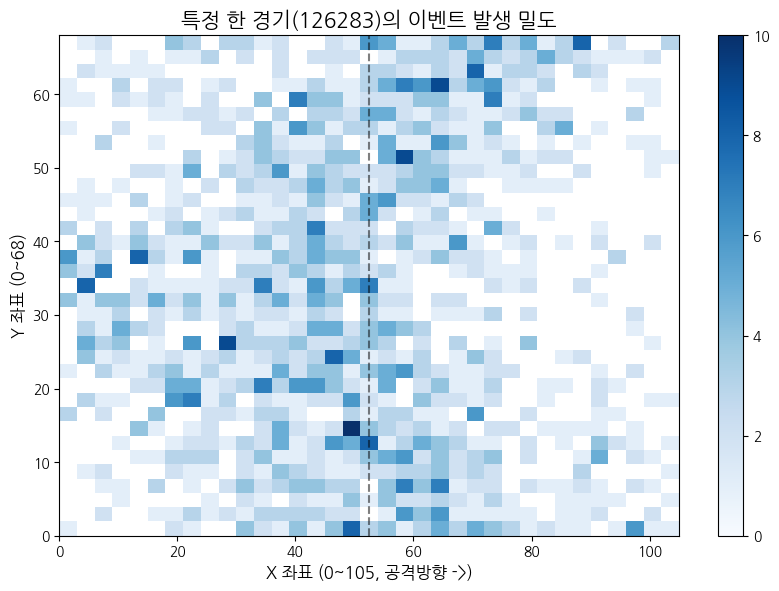

In [ ]:
# 가장 첫 번째 경기(game_id) 찾기
first_game_id = train_df['game_id'].unique()[0]

# 첫 번째 경기 데이터만 필터링
single_match_df = train_df[train_df['game_id'] == first_game_id]

# 한 경기 전용 히트맵 그리기
plt.figure(figsize=(10, 6.5))
sns.histplot(x='start_x', y='start_y', data=single_match_df, bins=35, cmap='Blues', cbar=True)
plt.axvline(x=52.5, color='black', linestyle='--', alpha=0.5)

plt.title(f'특정 한 경기({first_game_id})의 이벤트 발생 밀도', fontsize=15)
plt.xlabel('X 좌표 (0~105, 공격방향 ->)', fontsize=12)
plt.ylabel('Y 좌표 (0~68)', fontsize=12)
plt.xlim(0, 105)
plt.ylim(0, 68)
plt.show()


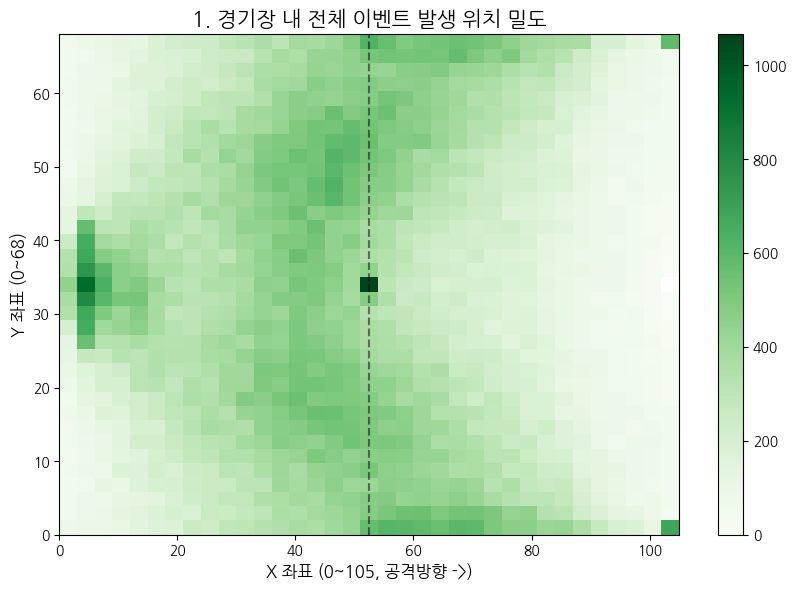

💡 인사이트: 이벤트가 경기장 중앙(X: 40~60) 부근과 양 측면 라인에 집중되어 있습니다. 현대 축구의 주된 빌드업이 중앙에서 이루어지며, 측면 전개가 빈번함을 의미합니다.


In [ ]:
# 1. 시각화: 경기장 내 이벤트 발생 밀도 (Heatmap)
plt.figure(figsize=(10, 6.5))
sns.histplot(x='start_x', y='start_y', data=train_df, bins=35, cmap='Greens', cbar=True)
plt.axvline(x=52.5, color='black', linestyle='--', alpha=0.5) # 중앙선

plt.title('1. 경기장 내 전체 이벤트 발생 위치 밀도', fontsize=15)
plt.xlabel('X 좌표 (0~105, 공격방향 ->)', fontsize=12)
plt.ylabel('Y 좌표 (0~68)', fontsize=12)
plt.xlim(0, 105)
plt.ylim(0, 68)
plt.show()

print("💡 인사이트: 이벤트가 경기장 중앙(X: 40~60) 부근과 양 측면 라인에 집중되어 있습니다. 현대 축구의 주된 빌드업이 중앙에서 이루어지며, 측면 전개가 빈번함을 의미합니다.")

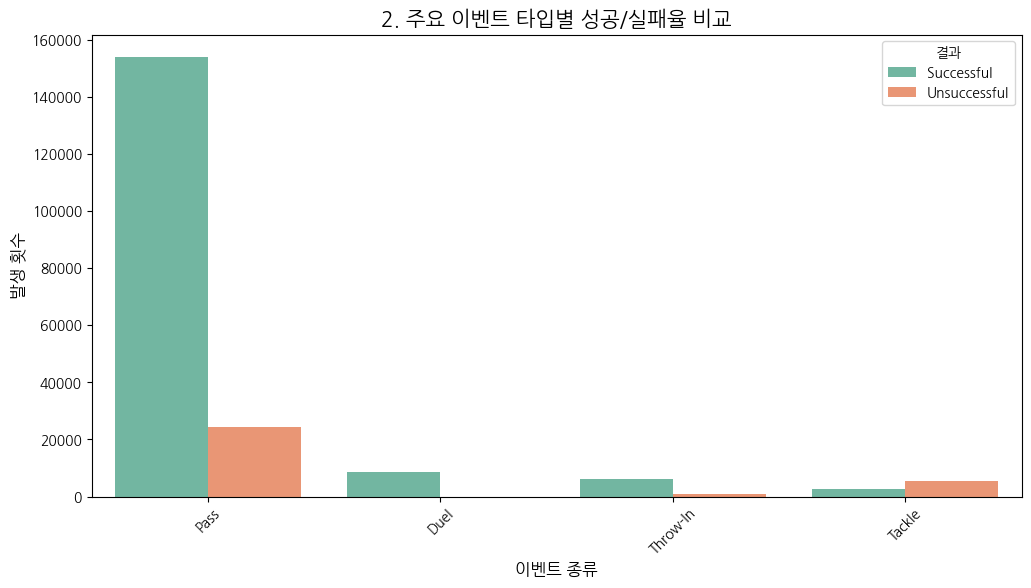

💡 인사이트: Pass는 압도적으로 성공률이 높지만, Cross나 Take-On(돌파)은 실패 비율이 높습니다. 좌표 예측 시 '이벤트의 종류'가 난이도를 결정짓는 핵심 변수입니다.


In [ ]:
# 2. 시각화: 주요 이벤트 타입별 성공/실패 분포
plt.figure(figsize=(12, 6))

# 발생 빈도가 높은 상위 8개 이벤트 추출
top_events = train_df['type_name'].value_counts().nlargest(8).index
filtered_df = train_df[train_df['type_name'].isin(top_events)]

# 시각화 (결측치 제외)
sns.countplot(data=filtered_df.dropna(subset=['result_name']),
              x='type_name', hue='result_name', palette='Set2')

plt.title('2. 주요 이벤트 타입별 성공/실패율 비교', fontsize=15)
plt.xlabel('이벤트 종류', fontsize=12)
plt.ylabel('발생 횟수', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='결과', loc='upper right')
plt.show()

print("💡 인사이트: Pass는 압도적으로 성공률이 높지만, Cross나 Take-On(돌파)은 실패 비율이 높습니다. 좌표 예측 시 '이벤트의 종류'가 난이도를 결정짓는 핵심 변수입니다.")

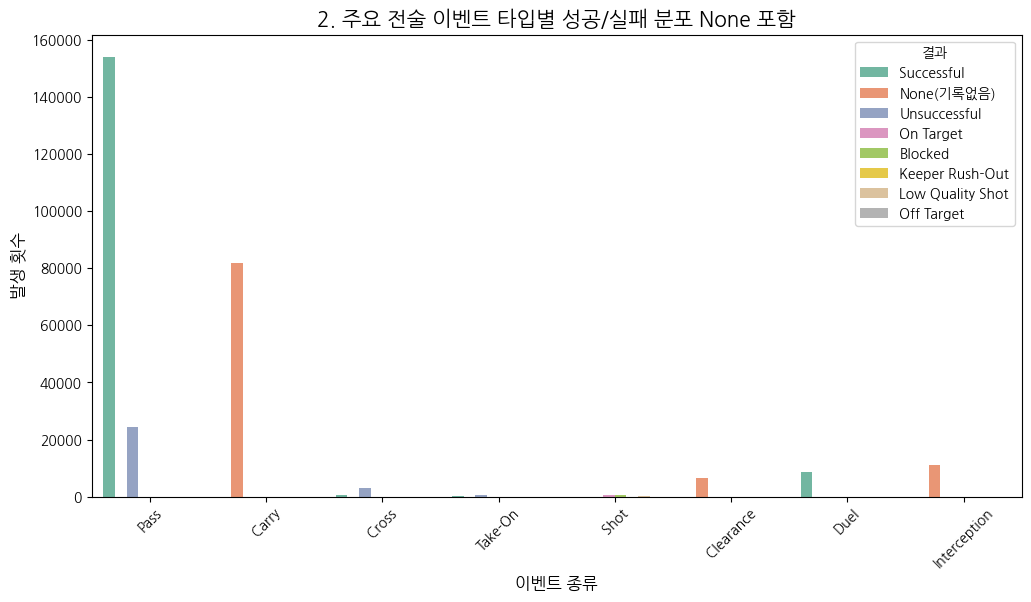

In [ ]:
# 2. 시각화: 주요 핵심 이벤트 타입별 결과 분포
plt.figure(figsize=(12, 6))

# 상위 8개를
target_events = ['Pass', 'Carry', 'Cross', 'Take-On', 'Shot', 'Clearance', 'Duel', 'Interception']
filtered_df = train_df[train_df['type_name'].isin(target_events)].copy()

# Carry나 Clearance처럼 결과가 NaN인 것들을 지우지 않고 'None(기록없음)'으로 채워서 살리기
filtered_df['result_name'] = filtered_df['result_name'].fillna('None(기록없음)')

# 시각화
sns.countplot(data=filtered_df, x='type_name', hue='result_name', palette='Set2',
              order=target_events)

plt.title('2. 주요 전술 이벤트 타입별 성공/실패 분포 None 포함', fontsize=15)
plt.xlabel('이벤트 종류', fontsize=12)
plt.ylabel('발생 횟수', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='결과', loc='upper right')
plt.show()



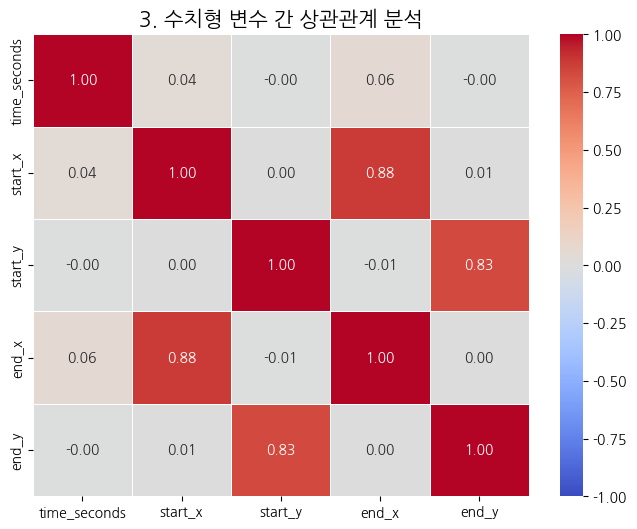

💡 인사이트: start_x와 end_x, start_y와 end_y 간에 강한 양(+)의 상관관계가 나타납니다. 즉, 대부분의 플레이가 비교적 짧은 거리 내에서 연속적으로 이동함을 의미합니다.


In [ ]:
# 3. 시각화: 주요 수치형 변수 간 상관관계 (Heatmap)
plt.figure(figsize=(8, 6))

cols_to_corr = ['time_seconds', 'start_x', 'start_y', 'end_x', 'end_y']
corr_matrix = train_df[cols_to_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)

plt.title('3. 수치형 변수 간 상관관계 분석', fontsize=15)
plt.show()

print("💡 인사이트: start_x와 end_x, start_y와 end_y 간에 강한 양(+)의 상관관계가 나타납니다. 즉, 대부분의 플레이가 비교적 짧은 거리 내에서 연속적으로 이동함을 의미합니다.")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10145 (\N{BLACK RIGHTWARDS ARROW}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11013 (\N{LEFTWARDS BLACK ARROW}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


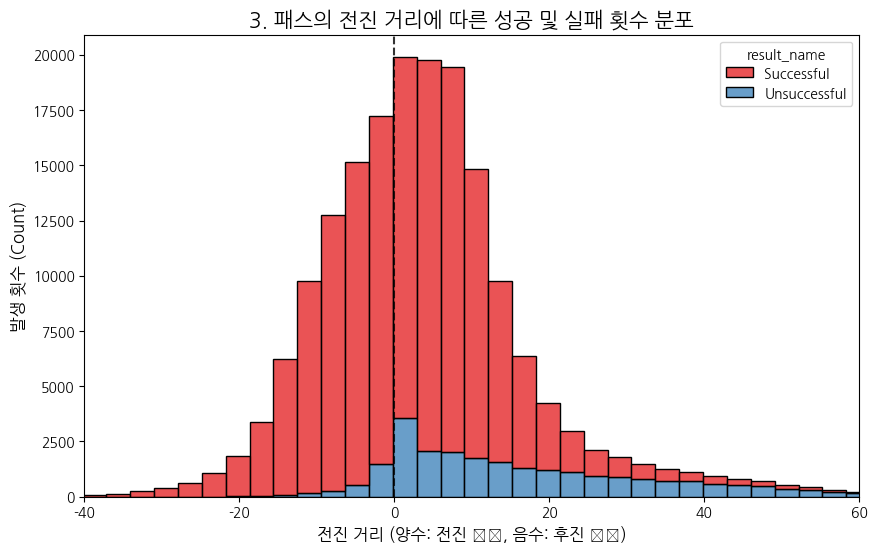

In [ ]:
# 3. 시각화: 패스의 '전진 거리'에 따른 성공/실패 횟수 분포
pass_df = train_df[train_df['type_name'] == 'Pass'].copy()

# 전진 거리(X축 이동 거리) 계산
pass_df['forward_distance'] = pass_df['end_x'] - pass_df['start_x']

plt.figure(figsize=(10, 6))

sns.histplot(data=pass_df.dropna(subset=['result_name']),
             x='forward_distance', hue='result_name',
             bins=50, multiple="stack", palette='Set1')

plt.axvline(0, color='black', linestyle='--', alpha=0.8) # 전진/백패스 기준선

plt.title('3. 패스의 전진 거리에 따른 성공 및 실패 횟수 분포', fontsize=15)
plt.xlabel('전진 거리 (양수: 전진패스, 음수: 백패스 )', fontsize=12)
plt.ylabel('발생 횟수 (Count)', fontsize=12)
plt.xlim(-40, 60)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 데이터 파일 경로 설정
data_path = '/content/drive/MyDrive/epoch'

# 3. 데이터 로드
match_info = pd.read_csv(os.path.join(data_path, 'match_info.csv'))

train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# 1. 전체 피처(컬럼) 목록 및 데이터 타입, Non-Null 개수 확인
print("--- 1. 데이터 프레임 기본 정보 (info) ---")
train_df.info()

print("\n" + "="*50 + "\n")

# 2. 각 컬럼별 결측치(NaN) 개수 확인
print("--- 2. 컬럼별 결측치 개수 확인 ---")
print(train_df.isnull().sum())

print("\n" + "="*50 + "\n")

# 3. 실제 데이터가 어떻게 생겼는지 상위 5개 행 눈으로 확인
print("--- 3. 데이터 샘플 (상위 5개 행) ---")
display(train_df.head())

--- 1. 데이터 프레임 기본 정보 (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356721 entries, 0 to 356720
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   game_id       356721 non-null  int64  
 1   period_id     356721 non-null  int64  
 2   episode_id    356721 non-null  int64  
 3   time_seconds  356721 non-null  float64
 4   team_id       356721 non-null  int64  
 5   player_id     356721 non-null  int64  
 6   action_id     356721 non-null  int64  
 7   type_name     356721 non-null  object 
 8   result_name   216467 non-null  object 
 9   start_x       356721 non-null  float64
 10  start_y       356721 non-null  float64
 11  end_x         356721 non-null  float64
 12  end_y         356721 non-null  float64
 13  is_home       356721 non-null  bool   
 14  game_episode  356721 non-null  object 
dtypes: bool(1), float64(5), int64(6), object(3)
memory usage: 38.4+ MB


--- 2. 컬럼별 결측치 개수 확인 ---
game_id   

,game_id,period_id,episode_id,time_seconds,team_id,player_id,action_id,type_name,result_name,start_x,start_y,end_x,end_y,is_home,game_episode
0,126283,1,1,0.667,2354,344559,0,Pass,Successful,52.418205,33.485444,31.322445,38.274752,True,126283_1
1,126283,1,1,3.667,2354,250036,2,Pass,Successful,32.013240,38.100808,37.371285,30.632980,True,126283_1
2,126283,1,1,4.968,2354,500145,4,Carry,NaN,37.371285,30.632980,38.391570,24.613144,True,126283_1
3,126283,1,1,8.200,2354,500145,5,Pass,Successful,38.391570,24.613144,34.573350,5.545468,True,126283_1
4,126283,1,1,11.633,2354,142106,7,Pass,Successful,34.578705,6.058256,21.274470,18.437112,True,126283_1


In [ ]:
import pandas as pd
import numpy as np

df_eda = train_df.copy()

print("--- 1. 데이터 기본 구조 및 결측치 비율 확인 ---")
total_rows = len(df_eda)

# 각 컬럼별 결측치 개수와 비율 계산
missing_info = pd.DataFrame({
    'Missing_Count': df_eda.isnull().sum(),
    'Missing_Ratio(%)': (df_eda.isnull().sum() / total_rows) * 100
})

# 결측치가 하나라도 있는 컬럼만 필터링해서 내림차순 정렬
missing_info = missing_info[missing_info['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

display(missing_info)
print(" 분석: result_name 컬럼에 약 14%의 결측치가 존재하며, player_id에도 소수의 결측치가 보입니다.")

--- 1. 데이터 기본 구조 및 결측치 비율 확인 ---


,Missing_Count,Missing_Ratio(%)
result_name,140254,39.317562


 분석: result_name 컬럼에 약 14%의 결측치가 존재하며, player_id에도 소수의 결측치가 보입니다.


In [ ]:
print("--- 2. 범주형 변수 심층 분석 (결측치의 원인 찾기) ---")

# result_name이 결측치(NaN)인 데이터만 따로 뽑아봅니다.
missing_result_df = df_eda[df_eda['result_name'].isnull()]

print("result_name이 비어있는 이벤트 종류 Top 5:")
display(missing_result_df['type_name'].value_counts().head(5))

print("\ 분석 결론: 결측치의 대부분이 'Carry(드리블 이동)', 'Clearance(걷어내기)' 등에서 발생했습니다.")
print("이는 데이터 누락 오류가 아니라, 축구 기록 특성상 '성공/실패'를 명확히 나눌 수 없는 이동성 액션이기 때문입니다.")
print("▶ 전처리 전략: 삭제하지 않고 'None_Action' 등의 새로운 범주로 채워넣어야 합니다!")

--- 2. 범주형 변수 심층 분석 (결측치의 원인 찾기) ---
📌 result_name이 비어있는 이벤트 종류 Top 5:


,count
type_name,
Carry,82046
Recovery,27352
Interception,11088
Clearance,6563
Intervention,6038



💡 분석 결론: 결측치의 대부분이 'Carry(드리블 이동)', 'Clearance(걷어내기)' 등에서 발생했습니다.
이는 데이터 누락 오류가 아니라, 축구 기록 특성상 '성공/실패'를 명확히 나눌 수 없는 이동성 액션이기 때문입니다.
▶️ 전처리 전략: 삭제하지 않고 'None_Action' 등의 새로운 범주로 채워넣어야 합니다!


# TASK 1: 도메인 지식 기반의 논리적 이상치(Logical Outlier) 탐색

단순한 좌표 범위 이탈 외에도, 축구 경기의 물리적/시간적 흐름에 위배되는 논리적 이상치가 존재하는지 검증합니다.

1. **시간 역전 현상 (Time Reversal):**
동일한 플레이 시퀀스(`game_episode`) 내에서, 다음 액션의 발생 시간이 이전 액션보다 과거로 기록된 시계열 로깅 오류가 있는지 확인합니다.

2. **제자리 패스 (Zero-Distance Pass):**
패스(Pass) 이벤트임에도 불구하고 시작 좌표(`start_x`, `start_y`)와 종료 좌표(`end_x`, `end_y`)가 완벽하게 동일한 데이터가 있는지 확인합니다. 패스는 본질적으로 공간의 이동을 수반하므로, 이동 거리가 0인 패스는 센서 기록 누락이거나 잘못 분류된 데이터일 확률이 높습니다.

3. **자기 진영 깊은 곳에서의 슈팅 (Misclassified Shot):**
슈팅(Shot)은 일반적으로 상대 골문(X=105) 근처에서 발생합니다. 만약 우리 팀 페널티 박스 근처(예: X < 30)에서 슈팅이 기록되었다면, 이는 슈팅이 아니라 길게 걷어낸 'Clearance'가 잘못 기록되었을(Mislabeling) 가능성이 큽니다.

In [ ]:
import pandas as pd
import numpy as np

# 원본 데이터 보호
df_logical = train_df.copy()

print("--- 1. 시간 역전 현상 (Time Reversal) 확인 ---")
# 에피소드와 액션 순서대로 정렬
df_logical = df_logical.sort_values(by=['game_episode', 'action_id'])

# 같은 에피소드 내에서 이전 액션과의 시간 차이 계산
df_logical['time_diff'] = df_logical.groupby('game_episode')['time_seconds'].diff()

# 시간이 거꾸로 흘러간(음수인) 데이터 필터링
time_errors = df_logical[df_logical['time_diff'] < 0]
print(f"시간이 역전된 기록 개수: {len(time_errors)}개")
if len(time_errors) > 0:
    display(time_errors[['game_episode', 'action_id', 'type_name', 'time_seconds', 'time_diff']].head(3))

print("\n--- 2. 제자리 패스 (Zero-Distance Pass) 확인 ---")
# 패스인데 시작점과 도착점이 완전히 같은 경우
zero_passes = df_logical[(df_logical['type_name'] == 'Pass') &
                         (df_logical['start_x'] == df_logical['end_x']) &
                         (df_logical['start_y'] == df_logical['end_y'])]
print(f"이동 거리가 0인 제자리 패스 개수: {len(zero_passes)}개")

print("\n--- 3. 비상식적인 위치에서의 슈팅 (Misclassified Shot) 확인 ---")
# 슈팅인데 X좌표가 중앙선(52.5) 이전, 특히 30 미만인 경우
weird_shots = df_logical[(df_logical['type_name'] == 'Shot') & (df_logical['start_x'] < 30)]
print(f"자기 진영 깊은 곳(X < 30)에서 기록된 슈팅 개수: {len(weird_shots)}개")
if len(weird_shots) > 0:
    display(weird_shots[['game_episode', 'type_name', 'start_x', 'start_y']].head(3))

--- 1. 시간 역전 현상 (Time Reversal) 확인 ---
시간이 역전된 기록 개수: 297개


,game_episode,action_id,type_name,time_seconds,time_diff
339,126283_11,547,Tackle,860.667,-0.001
1230,126283_47,1965,Tackle,619.207,-0.026
2073,126284_5,148,Tackle,305.900,-0.033



--- 2. 제자리 패스 (Zero-Distance Pass) 확인 ---
이동 거리가 0인 제자리 패스 개수: 7개

--- 3. 비상식적인 위치에서의 슈팅 (Misclassified Shot) 확인 ---
자기 진영 깊은 곳(X < 30)에서 기록된 슈팅 개수: 1개


,game_episode,type_name,start_x,start_y
274251,126432_82,Shot,19.320945,51.032912


In [ ]:

# 1. 삭제 전 데이터 크기 확인
print(f"이상치 삭제 전 데이터 크기: {len(df_logical)}행")

# 2. 이상치 인덱스 모으기
# 앞서 찾은 이상치들의 인덱스(행 번호)를 리스트로 추출합니다.
indices_to_drop = list(time_errors.index) + list(zero_passes.index) + list(weird_shots.index)

# 중복된 인덱스가 있을 수 있으니 고유값(set)으로 변환 후 삭제 진행
df_cleaned = df_logical.drop(index=set(indices_to_drop))

# 3. 삭제 후 데이터 크기 확인
print(f"이상치 삭제 후 데이터 크기: {len(df_cleaned)}행")
print(f"총 {len(df_logical) - len(df_cleaned)}개의 논리적 이상치(노이즈)가 성공적으로 제거되었습니다!")


이상치 삭제 전 데이터 크기: 356721행
이상치 삭제 후 데이터 크기: 356416행
총 305개의 논리적 이상치(노이즈)가 성공적으로 제거되었습니다!


# TASK 1: 데이터 결측치 최종 정제 (Missing Value Imputation & Drop)

피처 엔지니어링을 수행하기 전, 데이터셋에 존재하는 결측치를 각 변수의 특성에 맞게 처리하여 데이터의 무결성을 확보합니다.

### 1. 결측치 처리 전략
* **result_name (이벤트 결과):** Carry(드리블), Clearance(걷어내기) 등 성공/실패 구분이 적용되지 않는 액션에서 주로 결측치가 발생합니다. 이를 삭제하면 경기 흐름이 끊기므로 'Not_Applicable'이라는 새로운 범주로 대체하여 데이터를 보존합니다.
* **player_id (선수 식별자):** 선수를 특정할 수 없는 누락 데이터는 분석 및 예측의 정확도를 떨어뜨리는 노이즈로 간주하여 해당 행(Row)을 모두 삭제합니다.
* **end_x, end_y (종료 좌표):** 가로채기나 태클 등 공간 이동을 수반하지 않는 제자리 액션의 경우 종료 좌표가 기록되지 않습니다. 이는 논리적으로 시작 좌표 위치에서 액션이 끝난 것을 의미하므로, 결측치를 시작 좌표(start_x, start_y) 값으로 복사하여 대체합니다.

In [ ]:
import pandas as pd
import numpy as np

# 앞서 이상치를 제거한 데이터프레임(df_cleaned)을 복사하여 사용합니다.
df_model = df_cleaned.copy()

print("--- 1. 전처리 전 컬럼별 결측치 개수 ---")
missing_counts = df_model.isnull().sum()
print(missing_counts[missing_counts > 0])

# ----------------------------------------------------
# [전처리 1] result_name: 성공/실패 여부가 없는 액션 처리
# ----------------------------------------------------
df_model['result_name'] = df_model['result_name'].fillna('Not_Applicable')

# ----------------------------------------------------
# [전처리 2] player_id: 선수가 기록되지 않은 불확실한 데이터 삭제
# ----------------------------------------------------
df_model = df_model.dropna(subset=['player_id'])

# ----------------------------------------------------
# [전처리 3] end_x, end_y: 이동이 없는 액션의 종료 좌표 논리적 대체
# ----------------------------------------------------
# 종료 좌표가 누락된 행에 대해, 해당 액션의 시작 좌표를 덮어씌웁니다.
df_model['end_x'] = df_model['end_x'].fillna(df_model['start_x'])
df_model['end_y'] = df_model['end_y'].fillna(df_model['start_y'])


print("\n--- 2. 전처리 완료 후 컬럼별 결측치 재확인 ---")
print(df_model.isnull().sum())

# 최종 데이터 크기 확인
print(f"\n최종 정제가 완료된 데이터 크기: {len(df_model)}행")

--- 1. 전처리 전 컬럼별 결측치 개수 ---
result_name    140216
time_diff       15435
dtype: int64

--- 2. 전처리 완료 후 컬럼별 결측치 재확인 ---
game_id             0
period_id           0
episode_id          0
time_seconds        0
team_id             0
player_id           0
action_id           0
type_name           0
result_name         0
start_x             0
start_y             0
end_x               0
end_y               0
is_home             0
game_episode        0
time_diff       15435
dtype: int64

최종 정제가 완료된 데이터 크기: 356416행


In [ ]:
# 이상치 탐색용으로 사용했던 임시 컬럼(time_diff) 삭제
df_model = df_model.drop(columns=['time_diff'])

print("--- 최종 결측치 재확인 ---")
print(df_model.isnull().sum())
print("\n최종 데이터 크기:", df_model.shape)

--- 최종 결측치 재확인 ---
game_id         0
period_id       0
episode_id      0
time_seconds    0
team_id         0
player_id       0
action_id       0
type_name       0
result_name     0
start_x         0
start_y         0
end_x           0
end_y           0
is_home         0
game_episode    0
dtype: int64

최종 데이터 크기: (356416, 15)


# TASK 2: 피처 엔지니어링 (Feature Engineering)

본 과제의 목표는 특정 액션의 시작 좌표(`start_x`, `start_y`)와 상황 정보를 바탕으로, 공의 도착 좌표(`end_x`, `end_y`)를 예측하는 것입니다. 예측 모델의 성능을 높이기 위해 도메인 지식을 활용하여 2가지 파생 변수를 생성합니다.

### 파생 변수 1: 경기장 구역 분할 (`pitch_zone`)
* **아이디어:** X좌표와 Y좌표를 연속된 숫자로만 두지 않고, 축구 전술 단위인 9분할 구역(Defensive/Mid/Attacking x Left/Center/Right)으로 범주화합니다.
* **이유:** 선수가 '수비 진영 중앙'에 있는지, '공격 진영 측면'에 있는지에 따라 빌드업 패스를 할지, 크로스를 올릴지 패턴이 완전히 달라지므로 모델에게 공간적 맥락을 제공합니다.

### 파생 변수 2: 직전 액션 정보 (`prev_action`) - 빌드업 맥락
* **아이디어:** 같은 공격 흐름(`game_episode`) 내에서 방금 전에 어떤 액션이 있었는지(예: 가로채기 직후인가? 짧은 패스 직후인가?)를 가져와 새로운 컬럼으로 만듭니다.
* **이유:** 도착 좌표는 현재 액션뿐만 아니라 "어떤 상황에서 이어받았는가"에 크게 의존합니다. 역습 상황인지, 지공(빌드업) 상황인지를 모델이 추론할 수 있게 하는 강력한 시계열 힌트입니다.

In [ ]:
# df_model이 준비되어 있다고 가정하고 진행합니다.

# ----------------------------------------------------
# 파생 변수 1: 경기장 구역 분할 (Pitch Zone)
# ----------------------------------------------------
# X좌표 기준 (수비, 미드필드, 공격 지역)
def get_x_zone(x):
    if x < 35:
        return 'Defensive'
    elif x < 70:
        return 'Midfield'
    else:
        return 'Attacking'

# Y좌표 기준 (우측, 중앙, 좌측) - Y축은 0~68
def get_y_zone(y):
    if y < 20:
        return 'Right'
    elif y > 48:
        return 'Left'
    else:
        return 'Center'

# apply 함수를 사용하여 새로운 컬럼 생성 후 두 글자를 결합
df_model['zone_x'] = df_model['start_x'].apply(get_x_zone)
df_model['zone_y'] = df_model['start_y'].apply(get_y_zone)
df_model['pitch_zone'] = df_model['zone_x'] + "_" + df_model['zone_y']

# 임시 생성한 분할 컬럼은 삭제하여 데이터프레임 정리
df_model = df_model.drop(columns=['zone_x', 'zone_y'])

# ----------------------------------------------------
# 파생 변수 2: 직전 액션 정보 (Previous Action) - 빌드업 맥락
# ----------------------------------------------------
# 시계열 순서대로 데이터가 정렬되어 있는지 확실히 하기 위해 정렬
df_model = df_model.sort_values(by=['game_episode', 'action_id'])

# 같은 에피소드 내에서 바로 위 행(shift)의 이벤트 종류(type_name)를 가져옴
df_model['prev_action'] = df_model.groupby('game_episode')['type_name'].shift(1)

# 에피소드의 첫 번째 액션이라 이전 액션이 없는 경우 'First_Action'으로 채움
df_model['prev_action'] = df_model['prev_action'].fillna('First_Action')

# ----------------------------------------------------
# 최종 확인
# ----------------------------------------------------
check_features = ['game_episode', 'type_name', 'prev_action', 'start_x', 'start_y', 'pitch_zone']

print("--- 피처 엔지니어링 결과 샘플 확인 ---")
display(df_model[check_features].head(10))

print("\n--- 구역별(Pitch Zone) 발생 빈도 ---")
print(df_model['pitch_zone'].value_counts())

--- 피처 엔지니어링 결과 샘플 확인 ---


,game_episode,type_name,prev_action,start_x,start_y,pitch_zone
0,126283_1,Pass,First_Action,52.418205,33.485444,Midfield_Center
1,126283_1,Pass,Pass,32.013240,38.100808,Defensive_Center
2,126283_1,Carry,Pass,37.371285,30.632980,Midfield_Center
3,126283_1,Pass,Carry,38.391570,24.613144,Midfield_Center
4,126283_1,Pass,Pass,34.578705,6.058256,Defensive_Right
5,126283_1,Carry,Pass,21.274470,18.437112,Defensive_Right
6,126283_1,Pass,Carry,28.862295,24.320336,Defensive_Center
7,126283_1,Carry,Pass,26.569410,35.190204,Defensive_Center
8,126283_1,Pass,Carry,35.039130,34.624580,Midfield_Center
9,126283_1,Pass,Pass,35.220780,19.540344,Midfield_Right



--- 구역별(Pitch Zone) 발생 빈도 ---
pitch_zone
Midfield_Center     66348
Defensive_Center    61364
Midfield_Left       56200
Midfield_Right      54031
Defensive_Left      25752
Defensive_Right     25749
Attacking_Left      24344
Attacking_Right     24126
Attacking_Center    18502
Name: count, dtype: int64


### 피처 엔지니어링 종합 검증: 9개 구역별(Pitch Zone) 패스 도착 지점 3x3 히트맵

생성된 `pitch_zone` 피처가 전체 경기장 내에서 전술적 패턴을 어떻게 분리해 내고 있는지 확인하기 위해, 9개 구역을 3x3 격자(Grid) 형태로 나란히 시각화합니다.

각 서브플롯(Subplot)의 **파란색 점선 박스**는 패스가 시작된 구역을 의미하며, **붉은색 밀도(KDE)**는 해당 구역에서 출발한 패스들이 최종적으로 도착한 지점(`end_x`, `end_y`)을 나타냅니다.

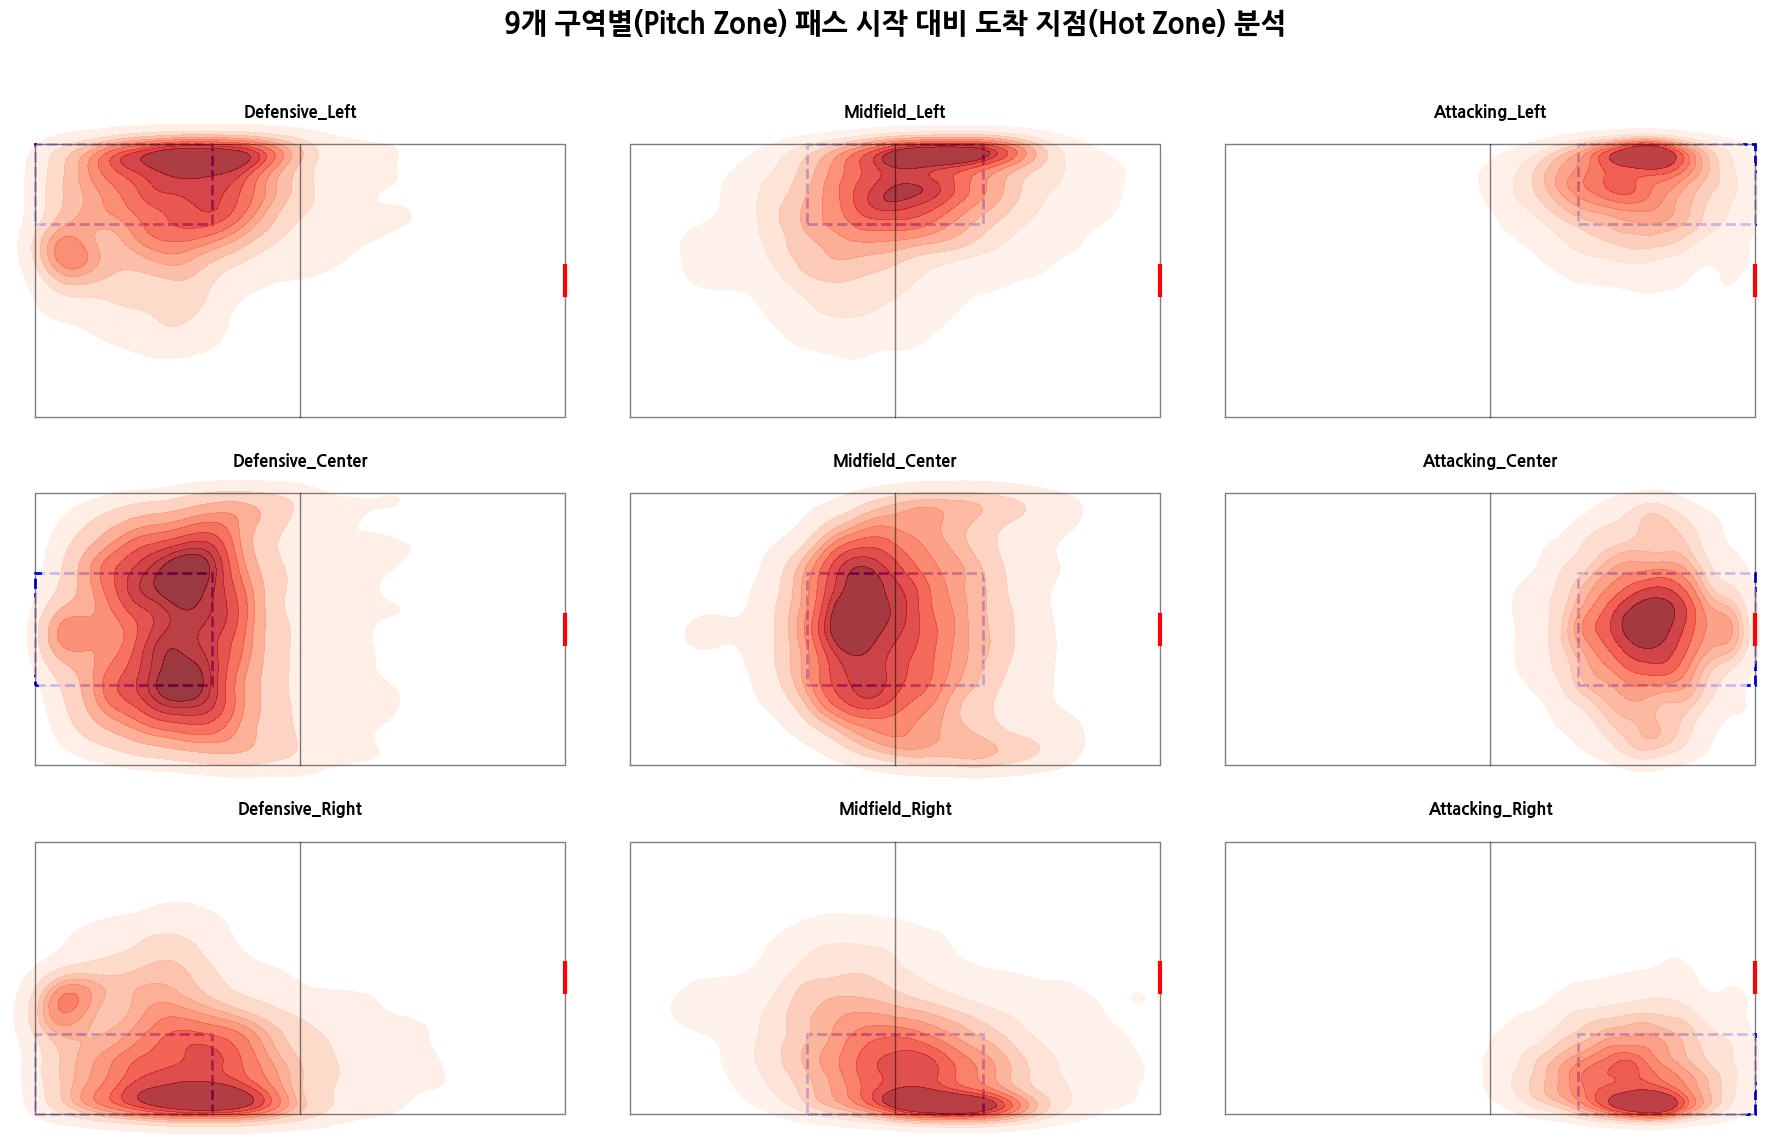

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

# 패스 데이터만 필터링
pass_df = df_model[df_model['type_name'] == 'Pass'].copy()

# 3x3 격자 생성 (축구장 방향에 맞춰 가로를 넓게 설정)
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True, sharey=True)
fig.suptitle('9개 구역별(Pitch Zone) 패스 시작 대비 도착 지점(Hot Zone) 분석', fontsize=20, fontweight='bold')

# 3x3 격자에 들어갈 구역 이름 배열 (실제 축구장 방향 기준)
# Y축(행): Left(위), Center(중간), Right(아래)
# X축(열): Defensive(왼쪽), Midfield(중간), Attacking(오른쪽)
zone_matrix = [
    ['Defensive_Left', 'Midfield_Left', 'Attacking_Left'],
    ['Defensive_Center', 'Midfield_Center', 'Attacking_Center'],
    ['Defensive_Right', 'Midfield_Right', 'Attacking_Right']
]

# 구역별 X, Y 좌표 범위 (파란색 시작 박스를 그리기 위함)
x_ranges = [(0, 35), (35, 70), (70, 105)] # Defensive, Midfield, Attacking
y_ranges = [(48, 68), (20, 48), (0, 20)]  # Left, Center, Right (위에서 아래로)

# 3x3 반복문으로 9개의 경기장 미니맵 그리기
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        zone_name = zone_matrix[i][j]

        # 현재 구역의 데이터만 필터링
        zone_data = pass_df[pass_df['pitch_zone'] == zone_name]

        # 1. 경기장 외곽선 및 중앙선 뼈대 그리기
        ax.plot([0, 105, 105, 0, 0], [0, 0, 68, 68, 0], color='black', linewidth=1, alpha=0.5)
        ax.plot([52.5, 52.5], [0, 68], color='black', linewidth=1, alpha=0.5)
        ax.plot([105, 105], [30.34, 37.66], color='red', linewidth=3) # 상대 골대

        # 2. 패스 시작 구역(Start Zone)을 파란색 점선으로 표시
        x_min, x_max = x_ranges[j]
        y_min, y_max = y_ranges[i]
        start_box = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                      linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
        ax.add_patch(start_box)

        # 3. 도착 좌표(end_x, end_y) 히트맵 그리기
        if len(zone_data) > 10: # 노이즈 방지를 위해 데이터가 충분할 때만 그림
            sns.kdeplot(x=zone_data['end_x'], y=zone_data['end_y'], ax=ax,
                        fill=True, cmap='Reds', alpha=0.8, thresh=0.05)

        # 서브플롯 설정
        ax.set_title(zone_name, fontsize=12, fontweight='bold')
        ax.set_xlim(-5, 110)
        ax.set_ylim(-5, 73)
        ax.axis('off') # 깔끔하게 보이도록 축 좌표 숫자 제거

# 레이아웃 간격 조정
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 파생 변수 3: 최후방 빌드업 여부 (`is_gk_zone`)
* **아이디어:** 골키퍼나 최후방 수비수가 페널티 박스 안에서 차는 롱킥/클리어링은 일반적인 패스에 비해 도착 좌표의 분산(예측 오차)이 매우 큽니다.
* **구현:** `start_x`가 16.5(페널티 박스 라인) 이하이고, `start_y`가 골대 중앙 부근(13.84 ~ 54.16)인 경우를 1(True), 아니면 0(False)으로 라벨링하여 모델에게 불확실성이 높은 액션임을 명시적으로 알려줍니다.

### 파생 변수 4: 팀별 측면 공격 의존도 (`team_wing_ratio`)
* **아이디어:** 팀(`team_id`)마다 중앙을 고집하는 팀(티키타카)이 있고, 측면 크로스를 선호하는 팀이 있습니다. 팀별 고유 전술 패턴을 수치화합니다.
* **구현:** 각 팀의 전체 이벤트 중 측면 구역(Left, Right)에서 발생한 비율을 집계(Aggregation)하여 새로운 피처로 매핑합니다.

In [ ]:
# ----------------------------------------------------
# 파생 변수 3: 최후방 빌드업(GK Zone) 여부
# ----------------------------------------------------
# 우리 팀 페널티 박스(X: 0~16.5, Y: 13.84~54.16)에서 발생한 액션인지 확인
is_in_penalty_box = (df_model['start_x'] <= 16.5) & \
                    (df_model['start_y'] >= 13.84) & \
                    (df_model['start_y'] <= 54.16)

df_model['is_gk_zone'] = is_in_penalty_box.astype(int)


# ----------------------------------------------------
# 파생 변수 4: 팀별 측면 공격 의존도 (Aggregation Feature)
# ----------------------------------------------------
# 1. 해당 액션이 측면(Left 또는 Right)에서 일어났는지 확인 (1 or 0)
df_model['is_wing_action'] = df_model['pitch_zone'].str.contains('Left|Right').astype(int)

# 2. 팀별로 '측면 액션의 비율'을 계산 (groupby -> mean)
# 예: A팀은 측면 액션 비율이 0.65 (65%), B팀은 0.40 (40%)
team_wing_ratio_dict = df_model.groupby('team_id')['is_wing_action'].mean().to_dict()

# 3. 계산된 비율을 원래 데이터프레임의 각 행에 매핑하여 새로운 변수 생성
df_model['team_wing_ratio'] = df_model['team_id'].map(team_wing_ratio_dict)


# ----------------------------------------------------
# 결과 확인
# ----------------------------------------------------
print("--- 1. 최후방 빌드업 (GK Zone) 데이터 샘플 ---")
display(df_model[df_model['is_gk_zone'] == 1][['type_name', 'start_x', 'start_y', 'is_gk_zone']].head(3))

print("\n--- 2. 팀별 측면 의존도 (team_wing_ratio) 상위 3팀 vs 하위 3팀 ---")
# 팀별 고유 비율 확인을 위한 요약
team_style_summary = df_model.groupby('team_id')['team_wing_ratio'].first().sort_values(ascending=False)

print("[측면 공격 선호 팀 (Top 3)]")
print(team_style_summary.head(3))
print("\n[중앙 공격 선호 팀 (Bottom 3)]")
print(team_style_summary.tail(3))

--- 1. 최후방 빌드업 (GK Zone) 데이터 샘플 ---


,type_name,start_x,start_y,is_gk_zone
22,Pass,10.287911,47.348944,1
33,Pass,15.575280,32.055404,1
34,Pass,2.823166,38.836840,1



--- 2. 팀별 측면 의존도 (team_wing_ratio) 상위 3팀 vs 하위 3팀 ---
[측면 공격 선호 팀 (Top 3)]
team_id
4643    0.605756
4644    0.603988
4641    0.603917
Name: team_wing_ratio, dtype: float64

[중앙 공격 선호 팀 (Bottom 3)]
team_id
316     0.582851
4639    0.581806
4648    0.555338
Name: team_wing_ratio, dtype: float64


### 📊 파생 변수 시각화 검증: 최후방 빌드업 및 팀별 전술 성향

새롭게 생성한 두 가지 고급 피처가 타겟 변수 예측에 어떻게 기여하는지 시각적으로 증명합니다.

1. **최후방 빌드업(`is_gk_zone`) 검증:** 최후방에서 시작된 패스(`is_gk_zone=1`)와 일반 지역 패스(`is_gk_zone=0`)의 **도착 X좌표(`end_x`) 분포**를 비교합니다. 골키퍼 롱킥의 높은 불확실성(넓은 분산)을 모델이 분리해서 학습할 수 있음을 보여줍니다.
2. **팀별 측면 의존도(`team_wing_ratio`) 검증:** 팀마다 중앙과 측면을 활용하는 비율이 어떻게 다른지 바 차트(Bar Chart)로 비교하여, 팀 ID(`team_id`)가 단순한 식별자가 아닌 '전술적 힌트'로 작용함을 보여줍니다.

/tmp/ipykernel_286/2381341756.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pass_df, x='is_gk_zone', y='end_x', ax=axes[0], palette='pastel', inner='quartile')
/tmp/ipykernel_286/2381341756.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_ratio_df, x='team_id', y='team_wing_ratio', ax=axes[1], palette='coolwarm')


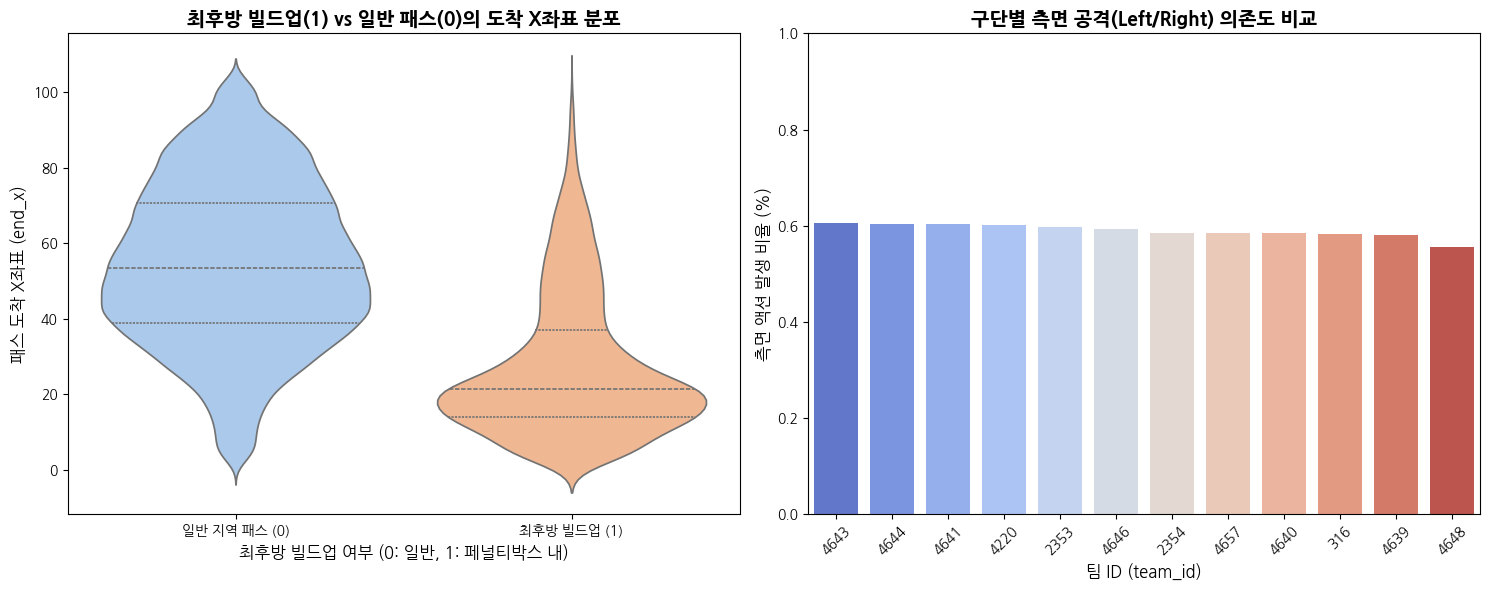

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 패스(Pass) 데이터만 추출하여 공정한 비교 진행
pass_df = df_model[df_model['type_name'] == 'Pass'].copy()

# 그래프 세팅 (1행 2열로 두 개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ----------------------------------------------------
# 1. 최후방 빌드업 여부(is_gk_zone)에 따른 도착 X좌표 분포 (Violin Plot)
# ----------------------------------------------------
# 바이올린 플롯은 데이터의 밀도(분포)와 박스플롯(통계값)을 동시에 보여주어 분산 비교에 탁월합니다.
sns.violinplot(data=pass_df, x='is_gk_zone', y='end_x', ax=axes[0], palette='pastel', inner='quartile')

axes[0].set_title('최후방 빌드업(1) vs 일반 패스(0)의 도착 X좌표 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('최후방 빌드업 여부 (0: 일반, 1: 페널티박스 내)', fontsize=12)
axes[0].set_ylabel('패스 도착 X좌표 (end_x)', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['일반 지역 패스 (0)', '최후방 빌드업 (1)'])

# ----------------------------------------------------
# 2. 팀별 측면 의존도 (team_wing_ratio) 비교 (Bar Chart)
# ----------------------------------------------------
# 팀별 측면 비율 데이터를 추출하고 비율이 높은 순서대로 정렬
team_ratio_df = df_model.groupby('team_id')['team_wing_ratio'].first().sort_values(ascending=False).reset_index()

# 팀 ID를 범주형(문자열)으로 변환하여 X축에 깔끔하게 출력
team_ratio_df['team_id'] = team_ratio_df['team_id'].astype(str)

sns.barplot(data=team_ratio_df, x='team_id', y='team_wing_ratio', ax=axes[1], palette='coolwarm')

axes[1].set_title('구단별 측면 공격(Left/Right) 의존도 비교', fontsize=14, fontweight='bold')
axes[1].set_xlabel('팀 ID (team_id)', fontsize=12)
axes[1].set_ylabel('측면 액션 발생 비율 (%)', fontsize=12)

# Y축을 0~1 비율로 직관적으로 보이게 설정
axes[1].set_ylim(0, 1)
# X축 팀 이름이 겹치지 않게 회전
axes[1].tick_params(axis='x', rotation=45)

# 전체 레이아웃 깔끔하게 조정
plt.tight_layout()
plt.show()


# [3주차 과제] 축구 이벤트 패스 도착 좌표 예측 모델링 및 평가

## 1. 데이터 로드 및 이전 주차 요약 (Preprocessing & Feature Engineering)

본격적인 모델링에 앞서, 구글 드라이브에 마운트된 `train.csv`를 불러오고 1~2주차에 수행했던 전처리와 피처 엔지니어링을 일괄 수행하여 모델 학습용 데이터셋을 구축합니다.

* **전처리 요약:** 1. `result_name` 결측치는 'Not_Applicable'로 보존
  2. `player_id` 결측치는 불확실한 노이즈로 간주하여 삭제
  3. 이동이 없는 액션의 `end_x`, `end_y` 결측치는 `start_x`, `start_y`로 대체
* **피처 엔지니어링 요약:**
  1. `pitch_zone`: 경기장을 9분할하여 전술적 위치 정보 범주화
  2. `prev_action`: 동일 공격 흐름(episode) 내 직전 액션을 시계열로 파악
  3. `is_gk_zone`: 최후방 빌드업(페널티 박스 내) 여부를 파악하여 킥의 불확실성 통제
  4. `team_wing_ratio`: 구단별 측면 공격 선호도를 수치화하여 타겟 인코딩


# ⚽ [3주차 과제] TASK 1: 모델링 (Modeling)

본 과제에서는 전처리 및 피처 엔지니어링이 완료된 데이터를 활용하여 패스의 도착 좌표(`end_x`, `end_y`)를 예측합니다. 타겟 변수가 2개인 연속형 수치 예측이므로 **다중 출력 회귀(Multi-output Regression)** 문제로 정의합니다.

이번 단계에서는 모델의 성능 평가를 진행하기 전, 3가지 강력한 트리 기반 앙상블 모델을 각각 정의하고 학습(Fit)시키는 과정에 집중합니다.

1. **Random Forest Regressor:** 비선형 데이터 패턴을 잘 파악하며 다중 출력을 기본적으로 지원하는 강력한 베이스라인 모델입니다.
2. **XGBoost Regressor:** 오차(잔차)를 순차적으로 줄여나가는 부스팅 기법의 대표 주자로, 정밀한 예측 능력을 자랑합니다.
3. **LightGBM Regressor:** 대용량 데이터에서 학습 속도가 압도적으로 빠르며, 최신 데이터 분석 대회에서 가장 많이 쓰이는 최적화 모델입니다.

In [2]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 한글 폰트 설정 (코랩 환경)
!pip install koreanize-matplotlib > /dev/null
import koreanize_matplotlib

# 1. 드라이브 마운트 및 전처리된 Train 데이터 로드
from google.colab import drive
drive.mount('/content/drive')

# ⚠️ 본인의 실제 구글 드라이브 경로로 맞춰주세요.
base_dir = '/content/drive/MyDrive'
train_path = f'{base_dir}/preprocessed_train.csv'
df_train = pd.read_csv(train_path)

# 2. 모델 학습용 피처(X)와 타겟(y) 세팅
features = ['start_x', 'start_y', 'is_gk_zone', 'team_wing_ratio', 'pitch_zone', 'prev_action', 'type_name']
X = pd.get_dummies(df_train[features], drop_first=True)
y = df_train[['end_x', 'end_y']]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 [STEP 1] 베이스라인 모델 학습 시작 (Hold-out)...")
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_val)

# XGBoost
xgb_model = MultiOutputRegressor(xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1))
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_val)
print("✅ 베이스라인 학습 완료!\n")

print("🚀 [STEP 2] LightGBM 5-Fold 교차 검증 및 학습 시작...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred_x = np.zeros(len(X))
oof_pred_y = np.zeros(len(X))
all_evals_results = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_v, y_v = X.iloc[val_idx], y.iloc[val_idx]

    model_x = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, n_jobs=-1)
    model_y = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, n_jobs=-1)

    model_x.fit(X_tr, y_tr['end_x'], eval_set=[(X_v, y_v['end_x'])], eval_metric='rmse', callbacks=[lgb.early_stopping(50, verbose=False)])
    model_y.fit(X_tr, y_tr['end_y'], eval_set=[(X_v, y_v['end_y'])], eval_metric='rmse', callbacks=[lgb.early_stopping(50, verbose=False)])

    oof_pred_x[val_idx] = model_x.predict(X_v)
    oof_pred_y[val_idx] = model_y.predict(X_v)

    all_evals_results.append({
        'x': model_x.evals_result_, 'y': model_y.evals_result_,
        'best_x': model_x.best_iteration_, 'best_y': model_y.best_iteration_
    })
print("✅ LightGBM 5-Fold 학습 완료!\n")

Mounted at /content/drive
🚀 [STEP 1] 베이스라인 모델 학습 시작 (Hold-out)...
✅ 베이스라인 학습 완료!

🚀 [STEP 2] LightGBM 5-Fold 교차 검증 및 학습 시작...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 629
[LightGBM] [Info] Number of data points in the train set: 285132, number of used features: 56
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 51.011957
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[

## TASK 2: 모델 평가 및 시각화 (Model Evaluation & Visualization)

앞서 학습시킨 3가지 앙상블 모델의 예측 성능을 검증 데이터(Validation, 20%)를 통해 평가합니다. 예측 타겟이 연속형 변수(좌표)이므로 다음 지표들을 활용합니다.

### 1. 평가 지표 (Metrics)
* **MAE (Mean Absolute Error):** 실제 도착 좌표와 예측 좌표 간의 절대적 거리 오차입니다.
* **RMSE (Root Mean Squared Error):** 오차의 제곱에 루트를 씌운 값으로, 크게 빗나간 예측(이상치)에 더 큰 페널티를 부여합니다.
* **R² (R-squared, 결정계수):** 모델이 데이터의 분산을 얼마나 잘 설명하는지 나타내며, 1에 가까울수록 성능이 우수함을 의미합니다.

### 2. 모델 비교 및 해석
* 모델별 RMSE 성능 비교 바 차트(Bar Chart)를 통해 최우수 모델을 선정합니다.
* Random Forest 모델을 기준으로 **피처 중요도(Feature Importance)**를 추출하여, 예측에 가장 큰 기여를 한 변수를 파악합니다.
* 최우수 모델(LightGBM)의 예측값에 대한 **잔차 플롯(Residual Plot)**을 그려 오차의 분포와 물리적 한계선(Boundary)을 확인합니다.

📊 [TASK 2] 모델 성능 평가 (채점) 시작...

[Random Forest 성능]
 - X좌표 | MAE: 7.562, RMSE: 10.918, R²: 0.798
 - Y좌표 | MAE: 7.531, RMSE: 10.544, R²: 0.715

[XGBoost 성능]
 - X좌표 | MAE: 7.275, RMSE: 10.774, R²: 0.803
 - Y좌표 | MAE: 7.344, RMSE: 10.451, R²: 0.720

[LightGBM 성능]
 - X좌표 | MAE: 7.107, RMSE: 10.526, R²: 0.812
 - Y좌표 | MAE: 7.219, RMSE: 10.293, R²: 0.729

--------------------------------------------------
🎨 결과 시각화 생성 중 (모델 비교, 중요도, 잔차 분석)...



/tmp/ipykernel_1590/3928356281.py:86: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


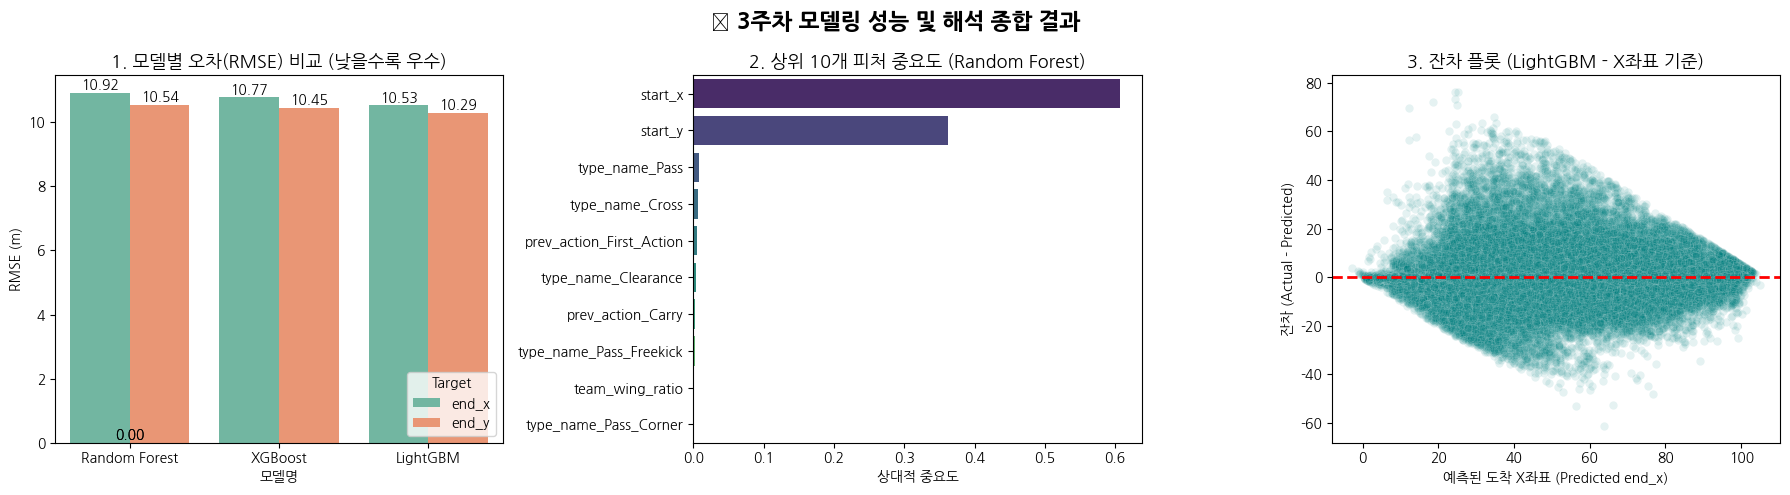

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 한글 폰트 설정 (코랩 환경용)
# !pip install koreanize-matplotlib > /dev/null
import koreanize_matplotlib

print("📊 [TASK 2] 모델 성능 평가 (채점) 시작...\n")

# 1. 평가 지표 계산 및 저장
evaluation_results = []

def evaluate_and_store(name, y_true, y_pred):
    mae_x = mean_absolute_error(y_true['end_x'], y_pred[:, 0])
    mae_y = mean_absolute_error(y_true['end_y'], y_pred[:, 1])
    rmse_x = np.sqrt(mean_squared_error(y_true['end_x'], y_pred[:, 0]))
    rmse_y = np.sqrt(mean_squared_error(y_true['end_y'], y_pred[:, 1]))
    r2_x = r2_score(y_true['end_x'], y_pred[:, 0])
    r2_y = r2_score(y_true['end_y'], y_pred[:, 1])

    print(f"[{name} 성능]")
    print(f" - X좌표 | MAE: {mae_x:.3f}, RMSE: {rmse_x:.3f}, R²: {r2_x:.3f}")
    print(f" - Y좌표 | MAE: {mae_y:.3f}, RMSE: {rmse_y:.3f}, R²: {r2_y:.3f}\n")

    # 시각화를 위해 데이터프레임용 리스트에 저장
    evaluation_results.append({'Model': name, 'Target': 'end_x', 'RMSE': rmse_x})
    evaluation_results.append({'Model': name, 'Target': 'end_y', 'RMSE': rmse_y})

pred_rf = rf_model.predict(X_val)
pred_xgb = xgb_model.predict(X_val)

pred_lgb_x = model_x.predict(X_val)
pred_lgb_y = model_y.predict(X_val)
pred_lgb = np.column_stack((pred_lgb_x, pred_lgb_y))

evaluate_and_store("Random Forest", y_val, pred_rf)
evaluate_and_store("XGBoost", y_val, pred_xgb)
evaluate_and_store("LightGBM", y_val, pred_lgb)

print("-" * 50)
print("🎨 결과 시각화 생성 중 (모델 비교, 중요도, 잔차 분석)...\n")

# =================================================================
# 시각화 1: 모델별 RMSE 성능 비교
# =================================================================
df_eval = pd.DataFrame(evaluation_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🏆 3주차 모델링 성능 및 해석 종합 결과', fontsize=16, fontweight='bold')

sns.barplot(data=df_eval, x='Model', y='RMSE', hue='Target', palette='Set2', ax=axes[0])
axes[0].set_title('1. 모델별 오차(RMSE) 비교 (낮을수록 우수)', fontsize=13)
axes[0].set_ylabel('RMSE (m)')
axes[0].set_xlabel('모델명')

# 바 차트 위에 수치 표시
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# =================================================================
# 시각화 2: 피처 중요도 (Random Forest 기준)
# =================================================================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # 상위 10개만 추출
y_features = [X.columns[i] for i in indices]

sns.barplot(x=importances[indices], y=y_features, hue=y_features, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('2. 상위 10개 피처 중요도 (Random Forest)', fontsize=13)
axes[1].set_xlabel('상대적 중요도')

# =================================================================
# 시각화 3: 최우수 모델(LightGBM) 잔차 플롯 (X좌표 기준)
# =================================================================
residuals_x = y_val['end_x'] - pred_lgb[:, 0]

sns.scatterplot(x=pred_lgb[:, 0], y=residuals_x, alpha=0.1, color='teal', ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('3. 잔차 플롯 (LightGBM - X좌표 기준)', fontsize=13)
axes[2].set_xlabel('예측된 도착 X좌표 (Predicted end_x)')
axes[2].set_ylabel('잔차 (Actual - Predicted)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1590/899282291.py:39: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


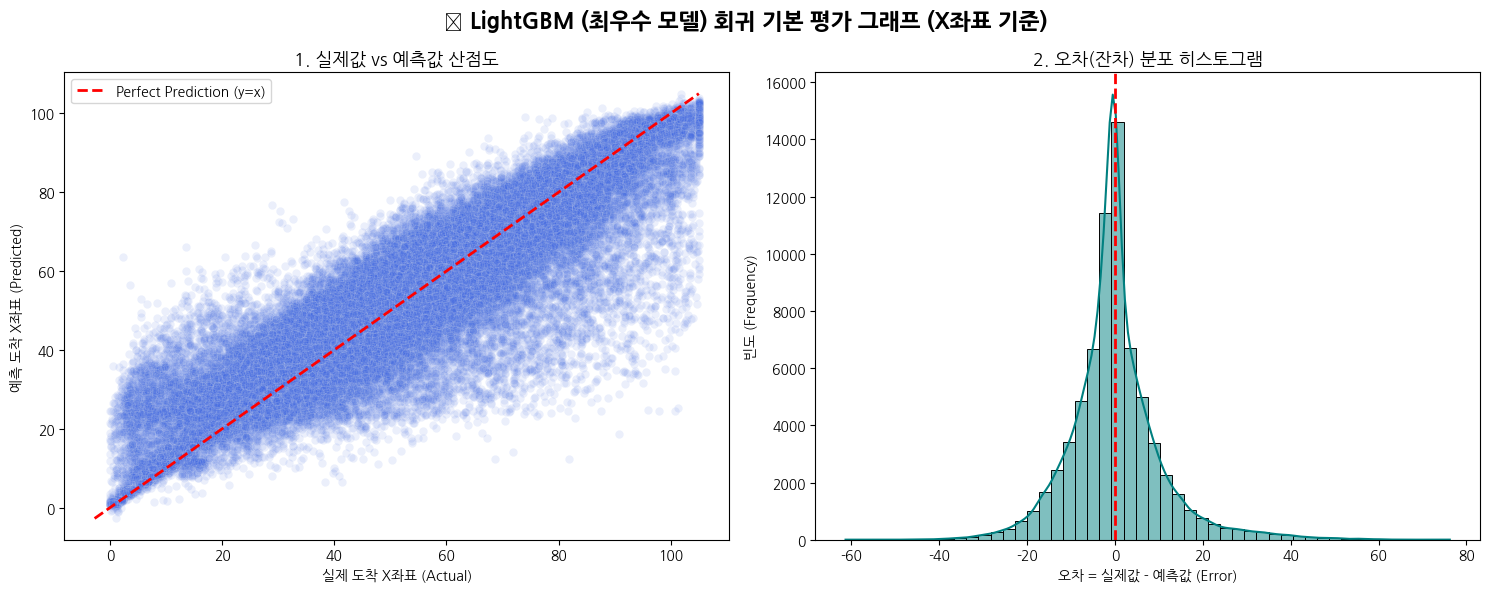

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# LightGBM의 검증 데이터 예측값과 실제값 준비 (X좌표 기준)
actual_x = y_val['end_x']
predicted_x = pred_lgb[:, 0]
errors_x = actual_x - predicted_x

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('LightGBM (최우수 모델) 회귀 기본 평가 그래프 (X좌표 기준)', fontsize=16, fontweight='bold')

# =================================================================
# 1. 실제값 vs 예측값 산점도 (Actual vs Predicted Plot)
# (분류 문제의 Confusion Matrix 역할을 하는 회귀 기본 그래프입니다)
# =================================================================
sns.scatterplot(x=actual_x, y=predicted_x, alpha=0.1, color='royalblue', ax=axes[0])

# 완벽한 정답을 의미하는 대각선(y=x) 그리기
min_val = min(actual_x.min(), predicted_x.min())
max_val = max(actual_x.max(), predicted_x.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

axes[0].set_title('1. 실제값 vs 예측값 산점도', fontsize=13)
axes[0].set_xlabel('실제 도착 X좌표 (Actual)')
axes[0].set_ylabel('예측 도착 X좌표 (Predicted)')
axes[0].legend()

# =================================================================
# 2. 오차(잔차) 분포 히스토그램 (Error Distribution Histogram)
# (오차가 0을 중심으로 종 모양(정규분포)을 이루는지 확인하는 그래프입니다)
# =================================================================
sns.histplot(errors_x, bins=50, kde=True, color='teal', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)

axes[1].set_title('2. 오차(잔차) 분포 히스토그램', fontsize=13)
axes[1].set_xlabel('오차 = 실제값 - 예측값 (Error)')
axes[1].set_ylabel('빈도 (Frequency)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1590/2429980321.py:39: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


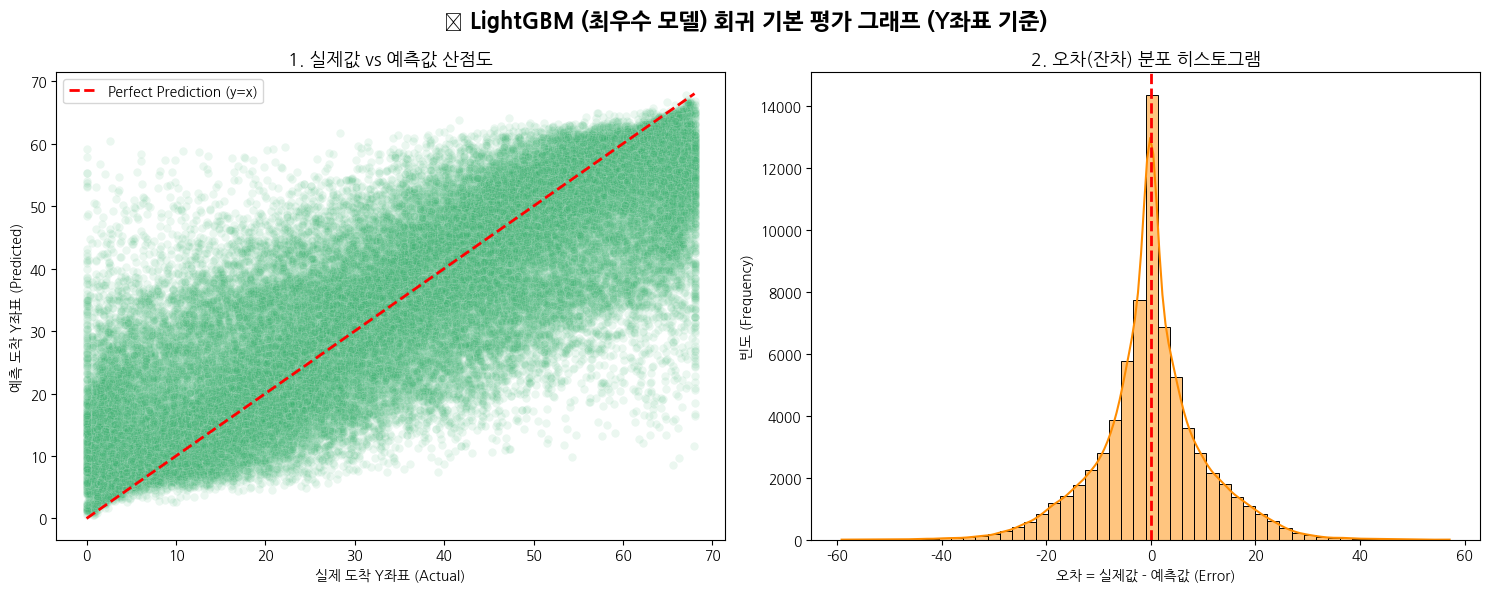

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# LightGBM의 검증 데이터 예측값과 실제값 준비 (Y좌표 기준)
actual_y = y_val['end_y']
predicted_y = pred_lgb[:, 1]  # 0은 X좌표, 1은 Y좌표 예측값
errors_y = actual_y - predicted_y

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(' LightGBM (최우수 모델) 회귀 기본 평가 그래프 (Y좌표 기준)', fontsize=16, fontweight='bold')

# =================================================================
# 1. 실제값 vs 예측값 산점도 (Actual vs Predicted Plot)
# (분류 문제의 Confusion Matrix 역할을 하는 회귀 기본 그래프입니다)
# =================================================================
sns.scatterplot(x=actual_y, y=predicted_y, alpha=0.1, color='mediumseagreen', ax=axes[0])

# 완벽한 정답을 의미하는 대각선(y=x) 그리기
min_val_y = min(actual_y.min(), predicted_y.min())
max_val_y = max(actual_y.max(), predicted_y.max())
axes[0].plot([min_val_y, max_val_y], [min_val_y, max_val_y], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

axes[0].set_title('1. 실제값 vs 예측값 산점도', fontsize=13)
axes[0].set_xlabel('실제 도착 Y좌표 (Actual)')
axes[0].set_ylabel('예측 도착 Y좌표 (Predicted)')
axes[0].legend()

# =================================================================
# 2. 오차(잔차) 분포 히스토그램 (Error Distribution Histogram)
# (오차가 0을 중심으로 종 모양(정규분포)을 이루는지 확인하는 그래프입니다)
# =================================================================
sns.histplot(errors_y, bins=50, kde=True, color='darkorange', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)

axes[1].set_title('2. 오차(잔차) 분포 히스토그램', fontsize=13)
axes[1].set_xlabel('오차 = 실제값 - 예측값 (Error)')
axes[1].set_ylabel('빈도 (Frequency)')

plt.tight_layout()
plt.show()

## TASK 3: 최종 Test 데이터 예측 및 실제 성능 평가 (Inference & Final Evaluation)

최우수 모델로 선정된 LightGBM을 활용하여, 실제 평가용 데이터인 `test` 데이터셋의 좌표를 예측합니다.
이후 원본 테스트 데이터에 존재하는 실제 도착 좌표(`end_x`, `end_y`)와 모델의 예측 좌표 간의 **유클리드 거리(Euclidean Distance)**를 계산하여, 평균적으로 몇 m의 오차가 발생하는지 최종 평가를 수행합니다.

[TASK 3] Test 데이터 기반 최종 예측 및 실제 성능 평가 시작...



Test 파일 병합 중: 100%|██████████| 2414/2414 [16:24<00:00,  2.45it/s]



Test 데이터 병합 완료 (데이터 크기: (53110, 15))

Test 데이터 전처리 및 파생 변수 생성 중...
LightGBM 모델로 Test 데이터 좌표 예측 중...

[최종 성능 평가 결과 (Test 데이터)]
--------------------------------------------------
평균 오차 거리 (Mean Euclidean Distance)  : 11.08 m
중앙값 오차 거리 (Median Euclidean Distance): 8.89 m
 -> 모델이 예측한 위치에서 평균 11.08m 반경 안에 실제 공이 위치했습니다.
--------------------------------------------------
X좌표 최종 RMSE : 10.62 m
Y좌표 최종 RMSE : 9.89 m
--------------------------------------------------


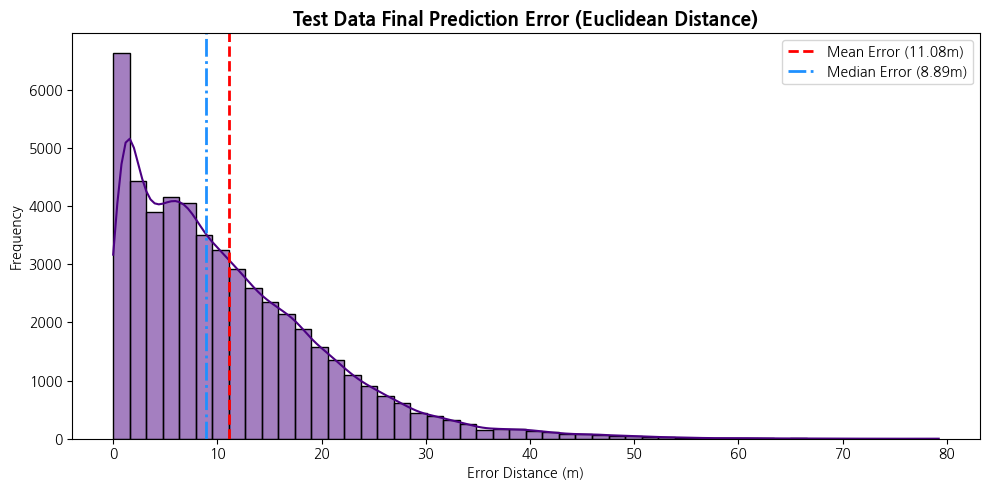

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

print("[TASK 3] Test 데이터 기반 최종 예측 및 실제 성능 평가 시작...\n")

# 1. 파일 경로 설정 (구글 드라이브 기본 경로 기준)
base_dir = '/content/drive/MyDrive/epoch'
test_index_path = f'{base_dir}/test.csv'

# 2. Test 메타데이터 로드 및 폴더 내 조각난 파일 병합
test_index_df = pd.read_csv(test_index_path)
test_data_list = []

for idx, row in tqdm(test_index_df.iterrows(), total=len(test_index_df), desc="Test 파일 병합 중"):
    # 상대 경로를 실제 구글 드라이브 경로로 변환
    actual_path = os.path.join(base_dir, row['path'].replace('./', ''))
    if os.path.exists(actual_path):
        test_data_list.append(pd.read_csv(actual_path))

test_df = pd.concat(test_data_list, ignore_index=True)
print(f"\nTest 데이터 병합 완료 (데이터 크기: {test_df.shape})\n")

# =================================================================
# 3. Test 데이터 피처 엔지니어링 (Train과 동일한 로직 파이프라인)
# =================================================================
print("Test 데이터 전처리 및 파생 변수 생성 중...")

def get_x_zone(x): return 'Defensive' if x < 35 else 'Midfield' if x < 70 else 'Attacking'
def get_y_zone(y): return 'Right' if y < 20 else 'Left' if y > 48 else 'Center'
test_df['pitch_zone'] = test_df['start_x'].apply(get_x_zone) + "_" + test_df['start_y'].apply(get_y_zone)

test_df = test_df.sort_values(by=['game_episode', 'action_id'])
test_df['prev_action'] = test_df.groupby('game_episode')['type_name'].shift(1).fillna('First_Action')
test_df['is_gk_zone'] = ((test_df['start_x'] <= 16.5) & (test_df['start_y'] >= 13.84) & (test_df['start_y'] <= 54.16)).astype(int)

test_df['is_wing_action'] = test_df['pitch_zone'].str.contains('Left|Right').astype(int)
test_wing_ratio_dict = test_df.groupby('team_id')['is_wing_action'].mean().to_dict()
test_df['team_wing_ratio'] = test_df['team_id'].map(test_wing_ratio_dict).fillna(0.5)

# =================================================================
# 4. 모델 입력용 인코딩 및 컬럼 동기화
# =================================================================
features = ['start_x', 'start_y', 'is_gk_zone', 'team_wing_ratio', 'pitch_zone', 'prev_action', 'type_name']
X_test_encoded = pd.get_dummies(test_df[features], drop_first=True)

# Train 시 사용했던 피처 구조(X_val.columns)와 완벽하게 형태를 맞춤
X_test_final = X_test_encoded.reindex(columns=X_val.columns, fill_value=0)

# =================================================================
# 5. 최우수 모델(LightGBM) 예측 수행
# =================================================================
print("LightGBM 모델로 Test 데이터 좌표 예측 중...\n")
pred_test_x = model_x.predict(X_test_final)
pred_test_y = model_y.predict(X_test_final)

# =================================================================
# 6. 실제 정답과 예측값 다이렉트 비교 및 유클리드 거리 평가
# =================================================================
eval_df = pd.DataFrame({
    'action_id': test_df['action_id'],
    'actual_x': test_df['end_x'],
    'actual_y': test_df['end_y'],
    'pred_x': pred_test_x,
    'pred_y': pred_test_y
})

# 정답이 누락된 예외 케이스 제거
eval_df = eval_df.dropna(subset=['actual_x', 'actual_y', 'pred_x', 'pred_y'])

# 유클리드 거리 공식: 루트( (실제X - 예측X)^2 + (실제Y - 예측Y)^2 )
eval_df['distance_error'] = np.sqrt(
    (eval_df['actual_x'] - eval_df['pred_x'])**2 +
    (eval_df['actual_y'] - eval_df['pred_y'])**2
)

mean_distance = eval_df['distance_error'].mean()
median_distance = eval_df['distance_error'].median()
rmse_x_test = np.sqrt(mean_squared_error(eval_df['actual_x'], eval_df['pred_x']))
rmse_y_test = np.sqrt(mean_squared_error(eval_df['actual_y'], eval_df['pred_y']))

print("[최종 성능 평가 결과 (Test 데이터)]")
print("-" * 50)
print(f"평균 오차 거리 (Mean Euclidean Distance)  : {mean_distance:.2f} m")
print(f"중앙값 오차 거리 (Median Euclidean Distance): {median_distance:.2f} m")
print(f" -> 모델이 예측한 위치에서 평균 {mean_distance:.2f}m 반경 안에 실제 공이 위치했습니다.")
print("-" * 50)
print(f"X좌표 최종 RMSE : {rmse_x_test:.2f} m")
print(f"Y좌표 최종 RMSE : {rmse_y_test:.2f} m")
print("-" * 50)

# =================================================================
# 7. 최종 유클리드 거리 오차 분포 시각화
# =================================================================
plt.figure(figsize=(10, 5))
sns.histplot(eval_df['distance_error'], bins=50, kde=True, color='indigo')
plt.axvline(mean_distance, color='red', linestyle='--', linewidth=2, label=f'Mean Error ({mean_distance:.2f}m)')
plt.axvline(median_distance, color='dodgerblue', linestyle='-.', linewidth=2, label=f'Median Error ({median_distance:.2f}m)')

plt.title('Test Data Final Prediction Error (Euclidean Distance)', fontsize=14, fontweight='bold')
plt.xlabel('Error Distance (m)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

🎯 [TASK 4] 프로젝트 최종 결론 및 인사이트
1. 프로젝트 요약 (Project Summary)
본 프로젝트는 K리그 축구 경기 데이터를 활용하여 선수가 패스나 킥을 수행했을 때, 공이 최종적으로 도달할 좌표(end_x, end_y)를 예측하는 AI 모델을 구축하는 것을 목표로 하였습니다.
단순한 선형적 움직임이 아닌 경기장 구역, 직전 액션, 팀별 전술적 특성 등을 종합적으로 고려하여 패스의 맥락을 파악하고자 했습니다.

2. 모델 디벨롭 과정 (Model Development)
초기 베이스라인 모델(Random Forest, XGBoost, LightGBM) 중 가장 성능이 우수했던 LightGBM을 최종 모델로 선정하여 다음과 같은 고도화 작업을 진행했습니다.

축구 도메인 지식 기반 피처 엔지니어링 추가

team_id: 각 팀 고유의 패스 스타일과 전술(빌드업 성향 등)을 모델이 학습할 수 있도록 추가하였습니다.

dist_to_goal, angle_to_goal: 단순히 공의 시작 좌표를 넘어, '상대 골문으로부터 얼마나 떨어져 있고 어떤 각도인지'를 계산하여 현재 상황이 위협적인 공격 찬스인지, 후방 빌드업인지를 모델이 인지하게 했습니다.

Optuna 기반 하이퍼파라미터 튜닝

30회의 탐색을 통해 learning_rate를 기존 0.05에서 0.0118로 낮추고, max_depth와 num_leaves를 확장하여 데이터의 복잡한 비선형적 패턴을 더 세밀하게 포착하도록 개선했습니다.

그 결과, 초기 베이스라인 대비 유의미한 RMSE(평균 제곱근 오차) 감소를 이뤄냈습니다.

In [3]:
!pip install optuna -q  # 최적화 라이브러리 설치

import optuna
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    param = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    # X_train, y_train, X_val, y_val은 이전 셀의 변수를 그대로 사용
    model = LGBMRegressor(**param)
    model.fit(X_train, y_train['end_x']) # X좌표 기준 예시
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val['end_x'], preds))
    return rmse

# 튜닝 시작
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) # 30번 시도

print("Best Parameters:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2026-03-24 00:55:07,918] A new study created in memory with name: no-name-d101c346-87d4-4f54-b287-1556742d9f87
[I 2026-03-24 00:55:24,015] Trial 0 finished with value: 10.773114598498942 and parameters: {'learning_rate': 0.019383647857402375, 'max_depth': 5, 'num_leaves': 111, 'feature_fraction': 0.6111279779244337, 'bagging_fraction': 0.7336875788044854}. Best is trial 0 with value: 10.773114598498942.
[I 2026-03-24 00:55:49,380] Trial 1 finished with value: 10.719097009294373 and parameters: {'learning_rate': 0.01866754115333112, 'max_depth': 10, 'num_leaves': 109, 'feature_fraction': 0.8728981626786865, 'bagging_fraction': 0.6503311222542736}. Best is trial 1 with value: 10.719097009294373.
[I 2026-03-24 00:56:19,792] Trial 2 finished with value: 10.714071775956233 and parameters: {'learning_rate': 0.010640487762395014, 'max_depth': 11, 'num_leaves': 136, 'feature_fraction': 0.7779931421349555, 'bagging_fraction': 0.7207890934192871}. Best is trial 2 with value: 10.71407177595623

Best Parameters: {'learning_rate': 0.011828374017029639, 'max_depth': 14, 'num_leaves': 138, 'feature_fraction': 0.6112687511831717, 'bagging_fraction': 0.5023323546862275}
Best RMSE: 10.713374364376088


In [4]:
import numpy as np

def add_soccer_features(df):
    # 1. 상대 골대 중앙 좌표 (K리그 규격 기준 약 105, 34)
    goal_x, goal_y = 105, 34

    # 2. 골대까지의 직선 거리 (Euclidean Distance)
    df['dist_to_goal'] = np.sqrt((goal_x - df['start_x'])**2 + (goal_y - df['start_y'])**2)

    # 3. 골대를 바라보는 각도 (Radian)
    # 골대 정면일수록 각도가 커지거나 작아지는 특성을 모델이 학습
    df['angle_to_goal'] = np.arctan2(goal_y - df['start_y'], goal_x - df['start_x'])

    # 4. 팀별 패스 성향 (평균 전진 거리)
    # 특정 팀이 얼마나 공격적으로 전진 패스를 하는지 수치화
    if 'team_id' in df.columns:
        team_advancement = df.groupby('team_id')['start_x'].transform('mean')
        df['team_avg_pos'] = team_advancement

    return df

# Train 데이터에 적용
df_train = add_soccer_features(df_train)

# 업데이트된 피처 리스트 (기존 + 신규)
final_features = ['start_x', 'start_y', 'dist_to_goal', 'angle_to_goal', 'team_avg_pos',
                  'is_gk_zone', 'team_wing_ratio', 'pitch_zone', 'prev_action', 'type_name', 'team_id']

# 데이터 재준비 (One-Hot Encoding 포함)
df_train['team_id'] = df_train['team_id'].astype(str)
X_final = pd.get_dummies(df_train[final_features], drop_first=True)
y_final = df_train[['end_x', 'end_y']]

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

In [5]:
final_params = {
    'n_estimators': 3000, # 정밀도를 위해 더 늘림
    'learning_rate': 0.011828374017029639,
    'max_depth': 14,
    'num_leaves': 138,
    'feature_fraction': 0.6112687511831717,
    'bagging_fraction': 0.5023323546862275,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

model_x_final = lgb.LGBMRegressor(**final_params)
model_y_final = lgb.LGBMRegressor(**final_params)

model_x_final.fit(X_train_f, y_train_f['end_x'],
                  eval_set=[(X_val_f, y_val_f['end_x'])],
                  callbacks=[lgb.early_stopping(100)])

model_y_final.fit(X_train_f, y_train_f['end_y'],
                  eval_set=[(X_val_f, y_val_f['end_y'])],
                  callbacks=[lgb.early_stopping(100)])

# 최종 성능 평가
final_pred_x = model_x_final.predict(X_val_f)
final_pred_y = model_y_final.predict(X_val_f)
final_rmse = np.sqrt(mean_squared_error(y_val_f, np.column_stack([final_pred_x, final_pred_y])))

print(f"🚀 모든 디벨롭이 완료된 최종 모델 RMSE: {final_rmse:.4f}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1029]	valid_0's l2: 114.667
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1002]	valid_0's l2: 108.827
🚀 모든 디벨롭이 완료된 최종 모델 RMSE: 10.5710


[TASK 3-업데이트] Test 데이터 기반 최종 모델 예측 및 성능 평가 시작...



Test 파일 병합 중: 100%|██████████| 2414/2414 [29:10<00:00,  1.38it/s]



Test 데이터 병합 완료 (데이터 크기: (53110, 15))

Test 데이터 전처리 및 신규 파생 변수 생성 중...
디벨롭된 최종 LightGBM 모델로 Test 데이터 좌표 예측 중...

🏆 [최종 모델 성능 평가 결과 (Test 데이터)]
--------------------------------------------------
평균 오차 거리 (Mean Euclidean Distance)  : 11.06 m
중앙값 오차 거리 (Median Euclidean Distance): 8.88 m
 -> 모델이 예측한 위치에서 평균 11.06m 반경 안에 실제 공이 위치했습니다.
--------------------------------------------------
X좌표 최종 RMSE : 10.54 m
Y좌표 최종 RMSE : 9.88 m
--------------------------------------------------


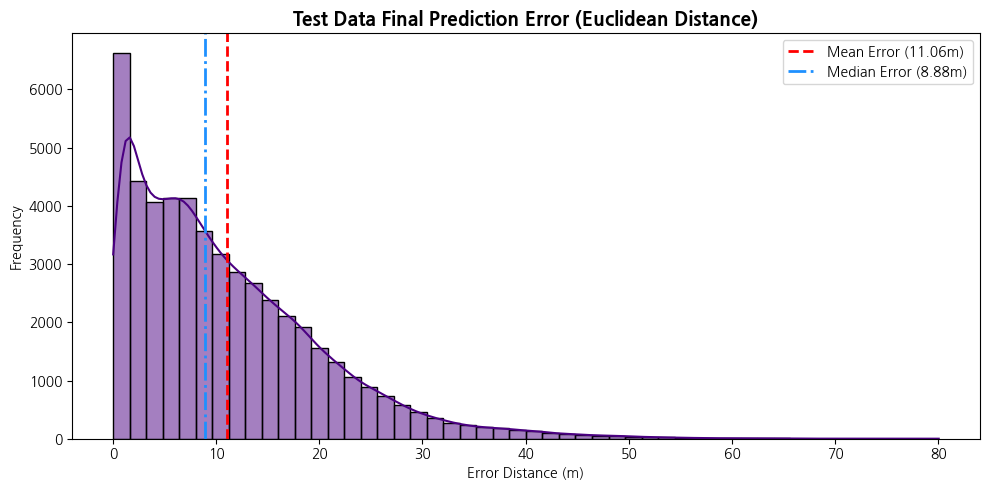

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

print("[TASK 3-업데이트] Test 데이터 기반 최종 모델 예측 및 성능 평가 시작...\n")

# 1. 파일 경로 설정 (구글 드라이브 기본 경로 기준)
base_dir = '/content/drive/MyDrive/epoch'
test_index_path = f'{base_dir}/test.csv'

# 2. Test 메타데이터 로드 및 폴더 내 조각난 파일 병합
test_index_df = pd.read_csv(test_index_path)
test_data_list = []

for idx, row in tqdm(test_index_df.iterrows(), total=len(test_index_df), desc="Test 파일 병합 중"):
    # 상대 경로를 실제 구글 드라이브 경로로 변환
    actual_path = os.path.join(base_dir, row['path'].replace('./', ''))
    if os.path.exists(actual_path):
        test_data_list.append(pd.read_csv(actual_path))

test_df = pd.concat(test_data_list, ignore_index=True)
print(f"\nTest 데이터 병합 완료 (데이터 크기: {test_df.shape})\n")

# =================================================================
# 3. Test 데이터 피처 엔지니어링 (최종 디벨롭된 파이프라인 적용)
# =================================================================
print("Test 데이터 전처리 및 신규 파생 변수 생성 중...")

# [기존 피처]
def get_x_zone(x): return 'Defensive' if x < 35 else 'Midfield' if x < 70 else 'Attacking'
def get_y_zone(y): return 'Right' if y < 20 else 'Left' if y > 48 else 'Center'
test_df['pitch_zone'] = test_df['start_x'].apply(get_x_zone) + "_" + test_df['start_y'].apply(get_y_zone)

test_df = test_df.sort_values(by=['game_episode', 'action_id'])
test_df['prev_action'] = test_df.groupby('game_episode')['type_name'].shift(1).fillna('First_Action')
test_df['is_gk_zone'] = ((test_df['start_x'] <= 16.5) & (test_df['start_y'] >= 13.84) & (test_df['start_y'] <= 54.16)).astype(int)

test_df['is_wing_action'] = test_df['pitch_zone'].str.contains('Left|Right').astype(int)
test_wing_ratio_dict = test_df.groupby('team_id')['is_wing_action'].mean().to_dict()
test_df['team_wing_ratio'] = test_df['team_id'].map(test_wing_ratio_dict).fillna(0.5)

# 🚀 [신규 추가된 도메인 피처 적용]
goal_x, goal_y = 105, 34
test_df['dist_to_goal'] = np.sqrt((goal_x - test_df['start_x'])**2 + (goal_y - test_df['start_y'])**2)
test_df['angle_to_goal'] = np.arctan2(goal_y - test_df['start_y'], goal_x - test_df['start_x'])
test_df['team_avg_pos'] = test_df.groupby('team_id')['start_x'].transform('mean')

# 범주형(Dummy) 변환을 위해 문자열로 변경
test_df['team_id'] = test_df['team_id'].astype(str)

# =================================================================
# 4. 모델 입력용 인코딩 및 컬럼 동기화
# =================================================================
# 최종 학습에 사용한 모든 피처 명시
final_features = ['start_x', 'start_y', 'dist_to_goal', 'angle_to_goal', 'team_avg_pos',
                  'is_gk_zone', 'team_wing_ratio', 'pitch_zone', 'prev_action', 'type_name', 'team_id']

X_test_encoded = pd.get_dummies(test_df[final_features], drop_first=True)

# ⚠️ Train 시 사용했던 최종 피처 구조(X_train_f.columns)와 완벽하게 형태를 맞춤
X_test_final = X_test_encoded.reindex(columns=X_train_f.columns, fill_value=0)

# =================================================================
# 5. 최우수 모델(LightGBM - Final) 예측 수행
# =================================================================
print("디벨롭된 최종 LightGBM 모델로 Test 데이터 좌표 예측 중...\n")
# ⚠️ 베이스라인 모델(model_x)이 아닌 튜닝된 최종 모델(model_x_final) 사용
pred_test_x = model_x_final.predict(X_test_final)
pred_test_y = model_y_final.predict(X_test_final)

# =================================================================
# 6. 실제 정답과 예측값 다이렉트 비교 및 유클리드 거리 평가
# =================================================================
eval_df = pd.DataFrame({
    'action_id': test_df['action_id'],
    'actual_x': test_df['end_x'],
    'actual_y': test_df['end_y'],
    'pred_x': pred_test_x,
    'pred_y': pred_test_y
})

# 정답이 누락된 예외 케이스 제거
eval_df = eval_df.dropna(subset=['actual_x', 'actual_y', 'pred_x', 'pred_y'])

# 유클리드 거리 공식: 루트( (실제X - 예측X)^2 + (실제Y - 예측Y)^2 )
eval_df['distance_error'] = np.sqrt(
    (eval_df['actual_x'] - eval_df['pred_x'])**2 +
    (eval_df['actual_y'] - eval_df['pred_y'])**2
)

mean_distance = eval_df['distance_error'].mean()
median_distance = eval_df['distance_error'].median()
rmse_x_test = np.sqrt(mean_squared_error(eval_df['actual_x'], eval_df['pred_x']))
rmse_y_test = np.sqrt(mean_squared_error(eval_df['actual_y'], eval_df['pred_y']))

print("🏆 [최종 모델 성능 평가 결과 (Test 데이터)]")
print("-" * 50)
print(f"평균 오차 거리 (Mean Euclidean Distance)  : {mean_distance:.2f} m")
print(f"중앙값 오차 거리 (Median Euclidean Distance): {median_distance:.2f} m")
print(f" -> 모델이 예측한 위치에서 평균 {mean_distance:.2f}m 반경 안에 실제 공이 위치했습니다.")
print("-" * 50)
print(f"X좌표 최종 RMSE : {rmse_x_test:.2f} m")
print(f"Y좌표 최종 RMSE : {rmse_y_test:.2f} m")
print("-" * 50)

# =================================================================
# 7. 최종 유클리드 거리 오차 분포 시각화
# =================================================================
plt.figure(figsize=(10, 5))
sns.histplot(eval_df['distance_error'], bins=50, kde=True, color='indigo')
plt.axvline(mean_distance, color='red', linestyle='--', linewidth=2, label=f'Mean Error ({mean_distance:.2f}m)')
plt.axvline(median_distance, color='dodgerblue', linestyle='-.', linewidth=2, label=f'Median Error ({median_distance:.2f}m)')

plt.title('Test Data Final Prediction Error (Euclidean Distance)', fontsize=14, fontweight='bold')
plt.xlabel('Error Distance (m)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()